In [1]:
import torch
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from protenix.utils.lmdb import LMDBDataset
from protenix.utils.plottool import init_plot_settings

import matplotlib.pyplot as plt

In [2]:
init_plot_settings()

In [3]:
lmdb = LMDBDataset("/data/rerank/protenix/chembl_bdb/chembl_bdb.lmdb")
lmdb.set_default_split("clean_keys_has_feature")
len(lmdb)

2354981

## Protein Sequence Statistics

In [5]:
sequences = {}
all_uniprot_ids = []
for sample in tqdm(lmdb, ncols=80):
   sequences[sample["uniprot_id"]] = sample["sequences"][0]['proteinChain']['sequence']
   all_uniprot_ids.append(sample["uniprot_id"])
seq_len = {key: len(value) for key, value in sequences.items()}

100%|██████████████████████████████| 2491307/2491307 [01:14<00:00, 33295.97it/s]


In [6]:
# write unique sequences into a fasta file
with open("/data/rerank/protenix/chembl_bdb/chembl_bdb_unique_sequences.fasta", "w") as f:
    for uniprot_id, sequence in sequences.items():
        f.write(f">{uniprot_id}\n")
        f.write(f"{sequence}\n")

In [14]:
max_len = max(seq_len.values())
min_len = min(seq_len.values())
median_len = sorted(seq_len.values())[len(seq_len) // 2]
print("Max length:", max_len)
print("Min length:", min_len)
print("Median length:", median_len)
print("Total number of unique uniprot ids:", len(sequences))

Max length: 7182
Min length: 9
Median length: 472
Total number of unique uniprot ids: 6019


Distribution of unique sequence lengths:


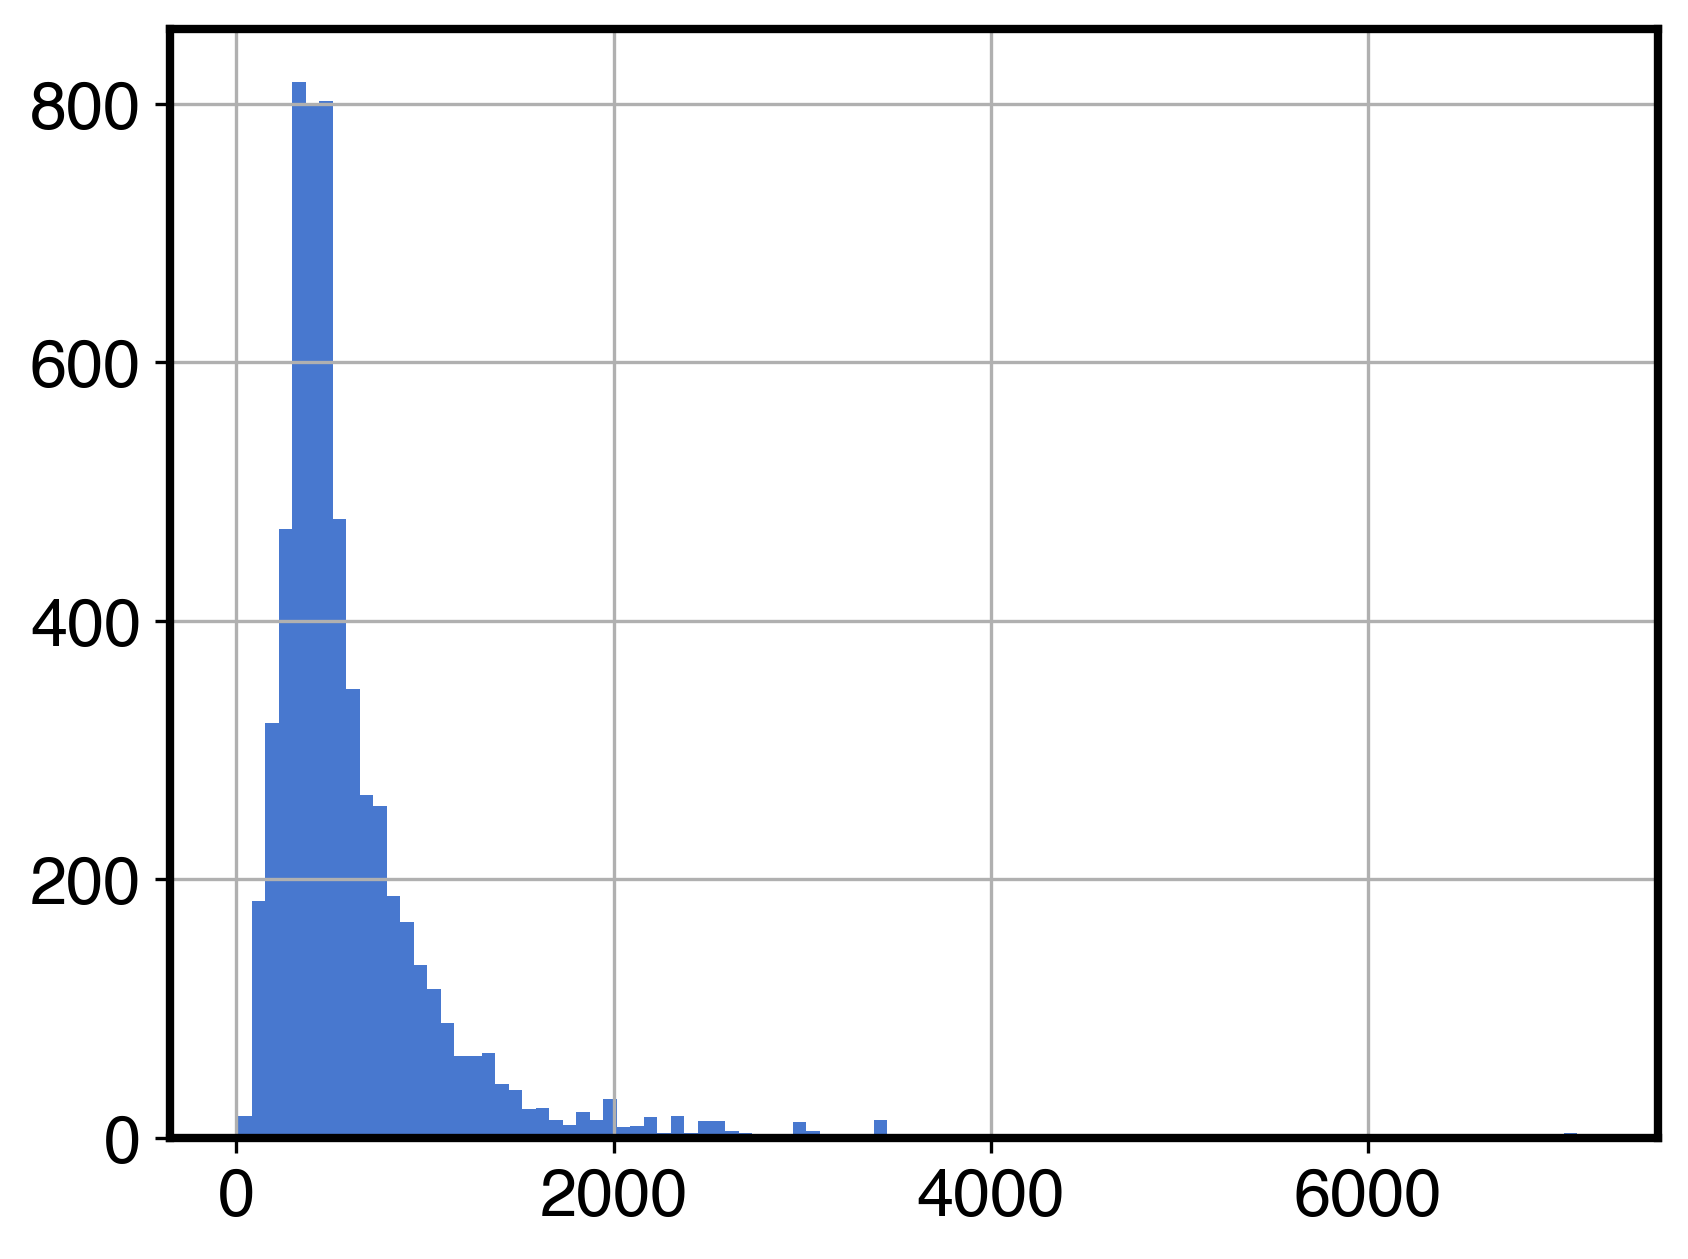

In [21]:
print("Distribution of unique sequence lengths:")
df = pd.DataFrame.from_dict(seq_len, orient="index", columns=["length"])
axis = df["length"].hist(bins=100)

Distribution of all sequence lengths:


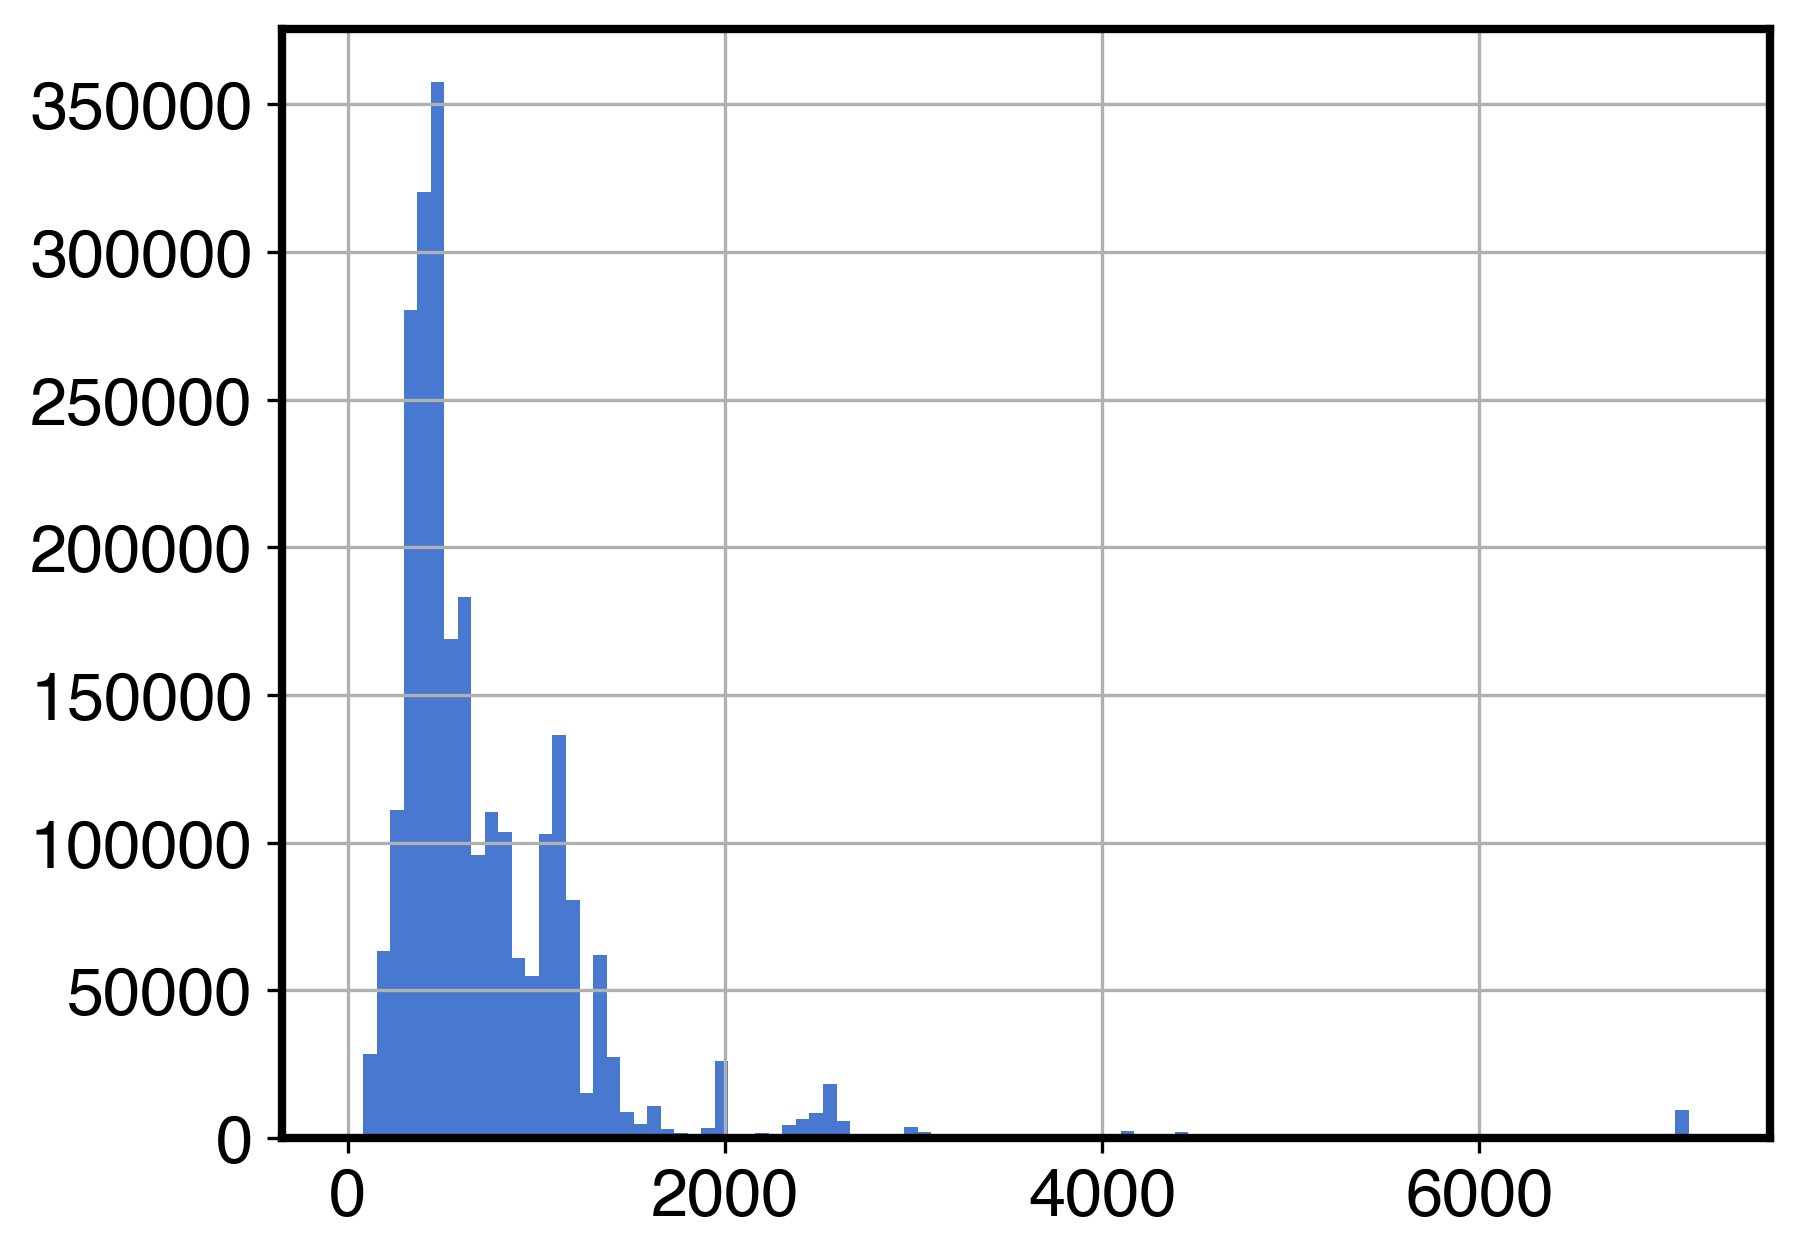

In [23]:
print("Distribution of all sequence lengths:")
all_seq_len = [seq_len[uniprot_id] for uniprot_id in all_uniprot_ids]
df = pd.DataFrame(all_seq_len, columns=["length"])
axis = df["length"].hist(bins=100)

In [26]:
print("Number of records below thresholds:")
print(f"total records: {len(all_seq_len)}")
print(f"below 2000: {len([x for x in all_seq_len if x < 2000])}")
print(f"below 1500: {len([x for x in all_seq_len if x < 1500])}")
print(f"below 1000: {len([x for x in all_seq_len if x < 1000])}")
print(f"below 500: {len([x for x in all_seq_len if x < 500])}")

Number of records below thresholds:
total records: 2491307
below 2000: 2413696
below 1500: 2370926
below 1000: 1935108
below 500: 1102408


## Record Statistics

In [49]:
lmdb = LMDBDataset("/data/rerank/protenix/chembl_bdb/chembl_bdb.lmdb")
clean_keys_has_feature = lmdb.get_split("clean_keys_has_feature")
print("Number of records with feature keys:", len(clean_keys_has_feature))

Number of records with feature keys: 2354981


In [24]:
with open("../scripts/split/splits/chembl_bdb.dude_litpcba_fep.30.json") as f:
    full_data_split_30 = json.load(f)
with open("../scripts/split/splits/chembl_bdb.dude_litpcba_fep.60.json") as f:
    full_data_split_60 = json.load(f)
with open("../scripts/split/splits/chembl_bdb.dude.30.json") as f:
    dude_split_30 = json.load(f)
with open("../scripts/split/splits/chembl_bdb.dude.60.json") as f:
    dude_split_60 = json.load(f)
with open("../scripts/split/splits/chembl_bdb.litpcba.30.json") as f:
    litpcba_split_30 = json.load(f)
with open("../scripts/split/splits/chembl_bdb.litpcba.60.json") as f:
    litpcba_split_60 = json.load(f)
with open("../scripts/split/splits/chembl_bdb.fep.30.json") as f:
    fep_split_30 = json.load(f)
with open("../scripts/split/splits/chembl_bdb.fep.60.json") as f:
    fep_split_60 = json.load(f)


In [8]:
keys_group_by_uniprot = {}
for key in clean_keys_has_feature:
    uniprot_id = key.split("_")[0]
    if uniprot_id not in keys_group_by_uniprot:
        keys_group_by_uniprot[uniprot_id] = []
    keys_group_by_uniprot[uniprot_id].append(key)

records per uniprot id:


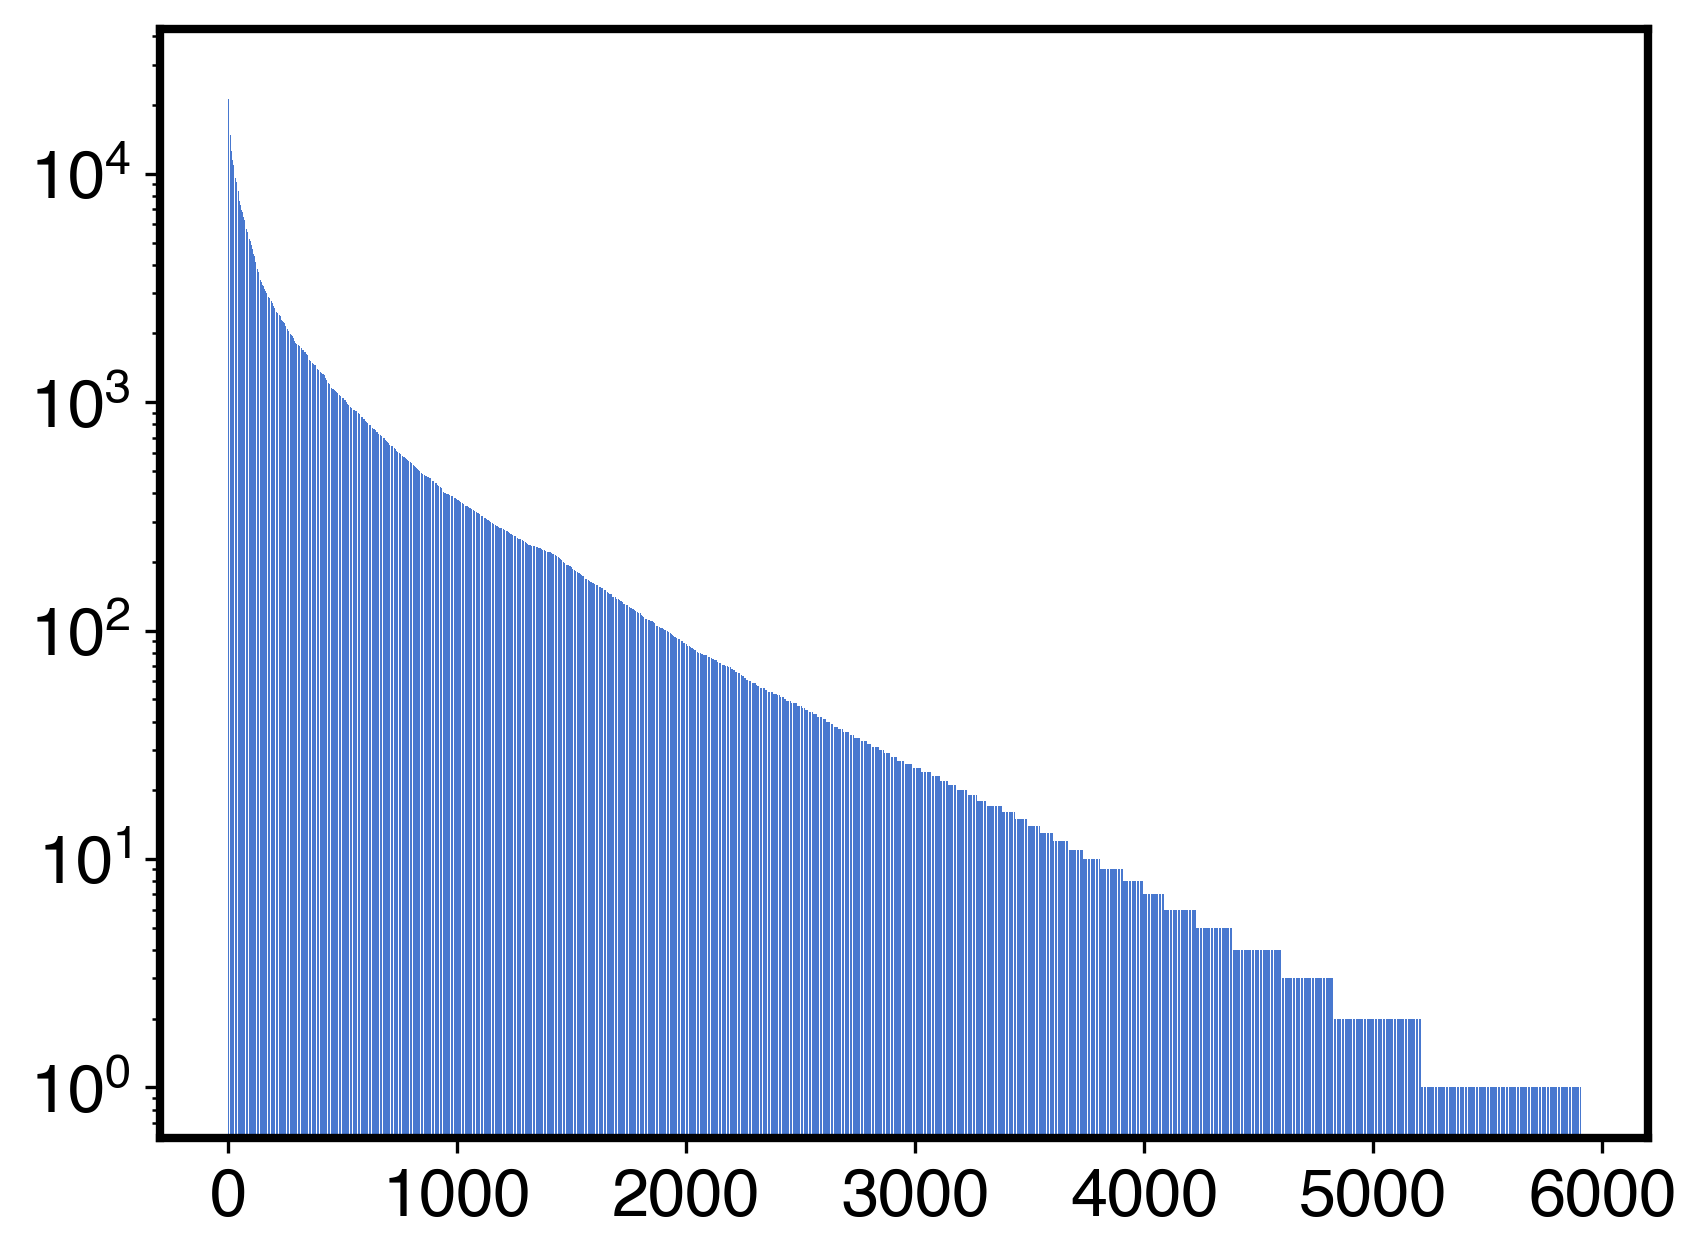

In [16]:
# plot bar chart of number of records per uniprot id
print("records per uniprot id:")
keys_group_by_uniprot_count = {
    key: len(value) for key, value in keys_group_by_uniprot.items()
}
plt.bar(
    range(len(keys_group_by_uniprot_count)),
    sorted(list(keys_group_by_uniprot_count.values()))[::-1],
)
# log scale
plt.yscale("log")

In [121]:
def statistics_by_split(data_split, keys_group_by_uniprot):
    train_uniprotids = set(data_split["train"])
    valid_uniprotids = set(data_split["valid"])
    total_train_keys = 0
    total_valid_keys = 0
    for uniprot_id, keys in keys_group_by_uniprot.items():
        if uniprot_id in train_uniprotids:
            total_train_keys += len(keys)
        elif uniprot_id in valid_uniprotids:
            total_valid_keys += len(keys)
    return total_train_keys, total_valid_keys

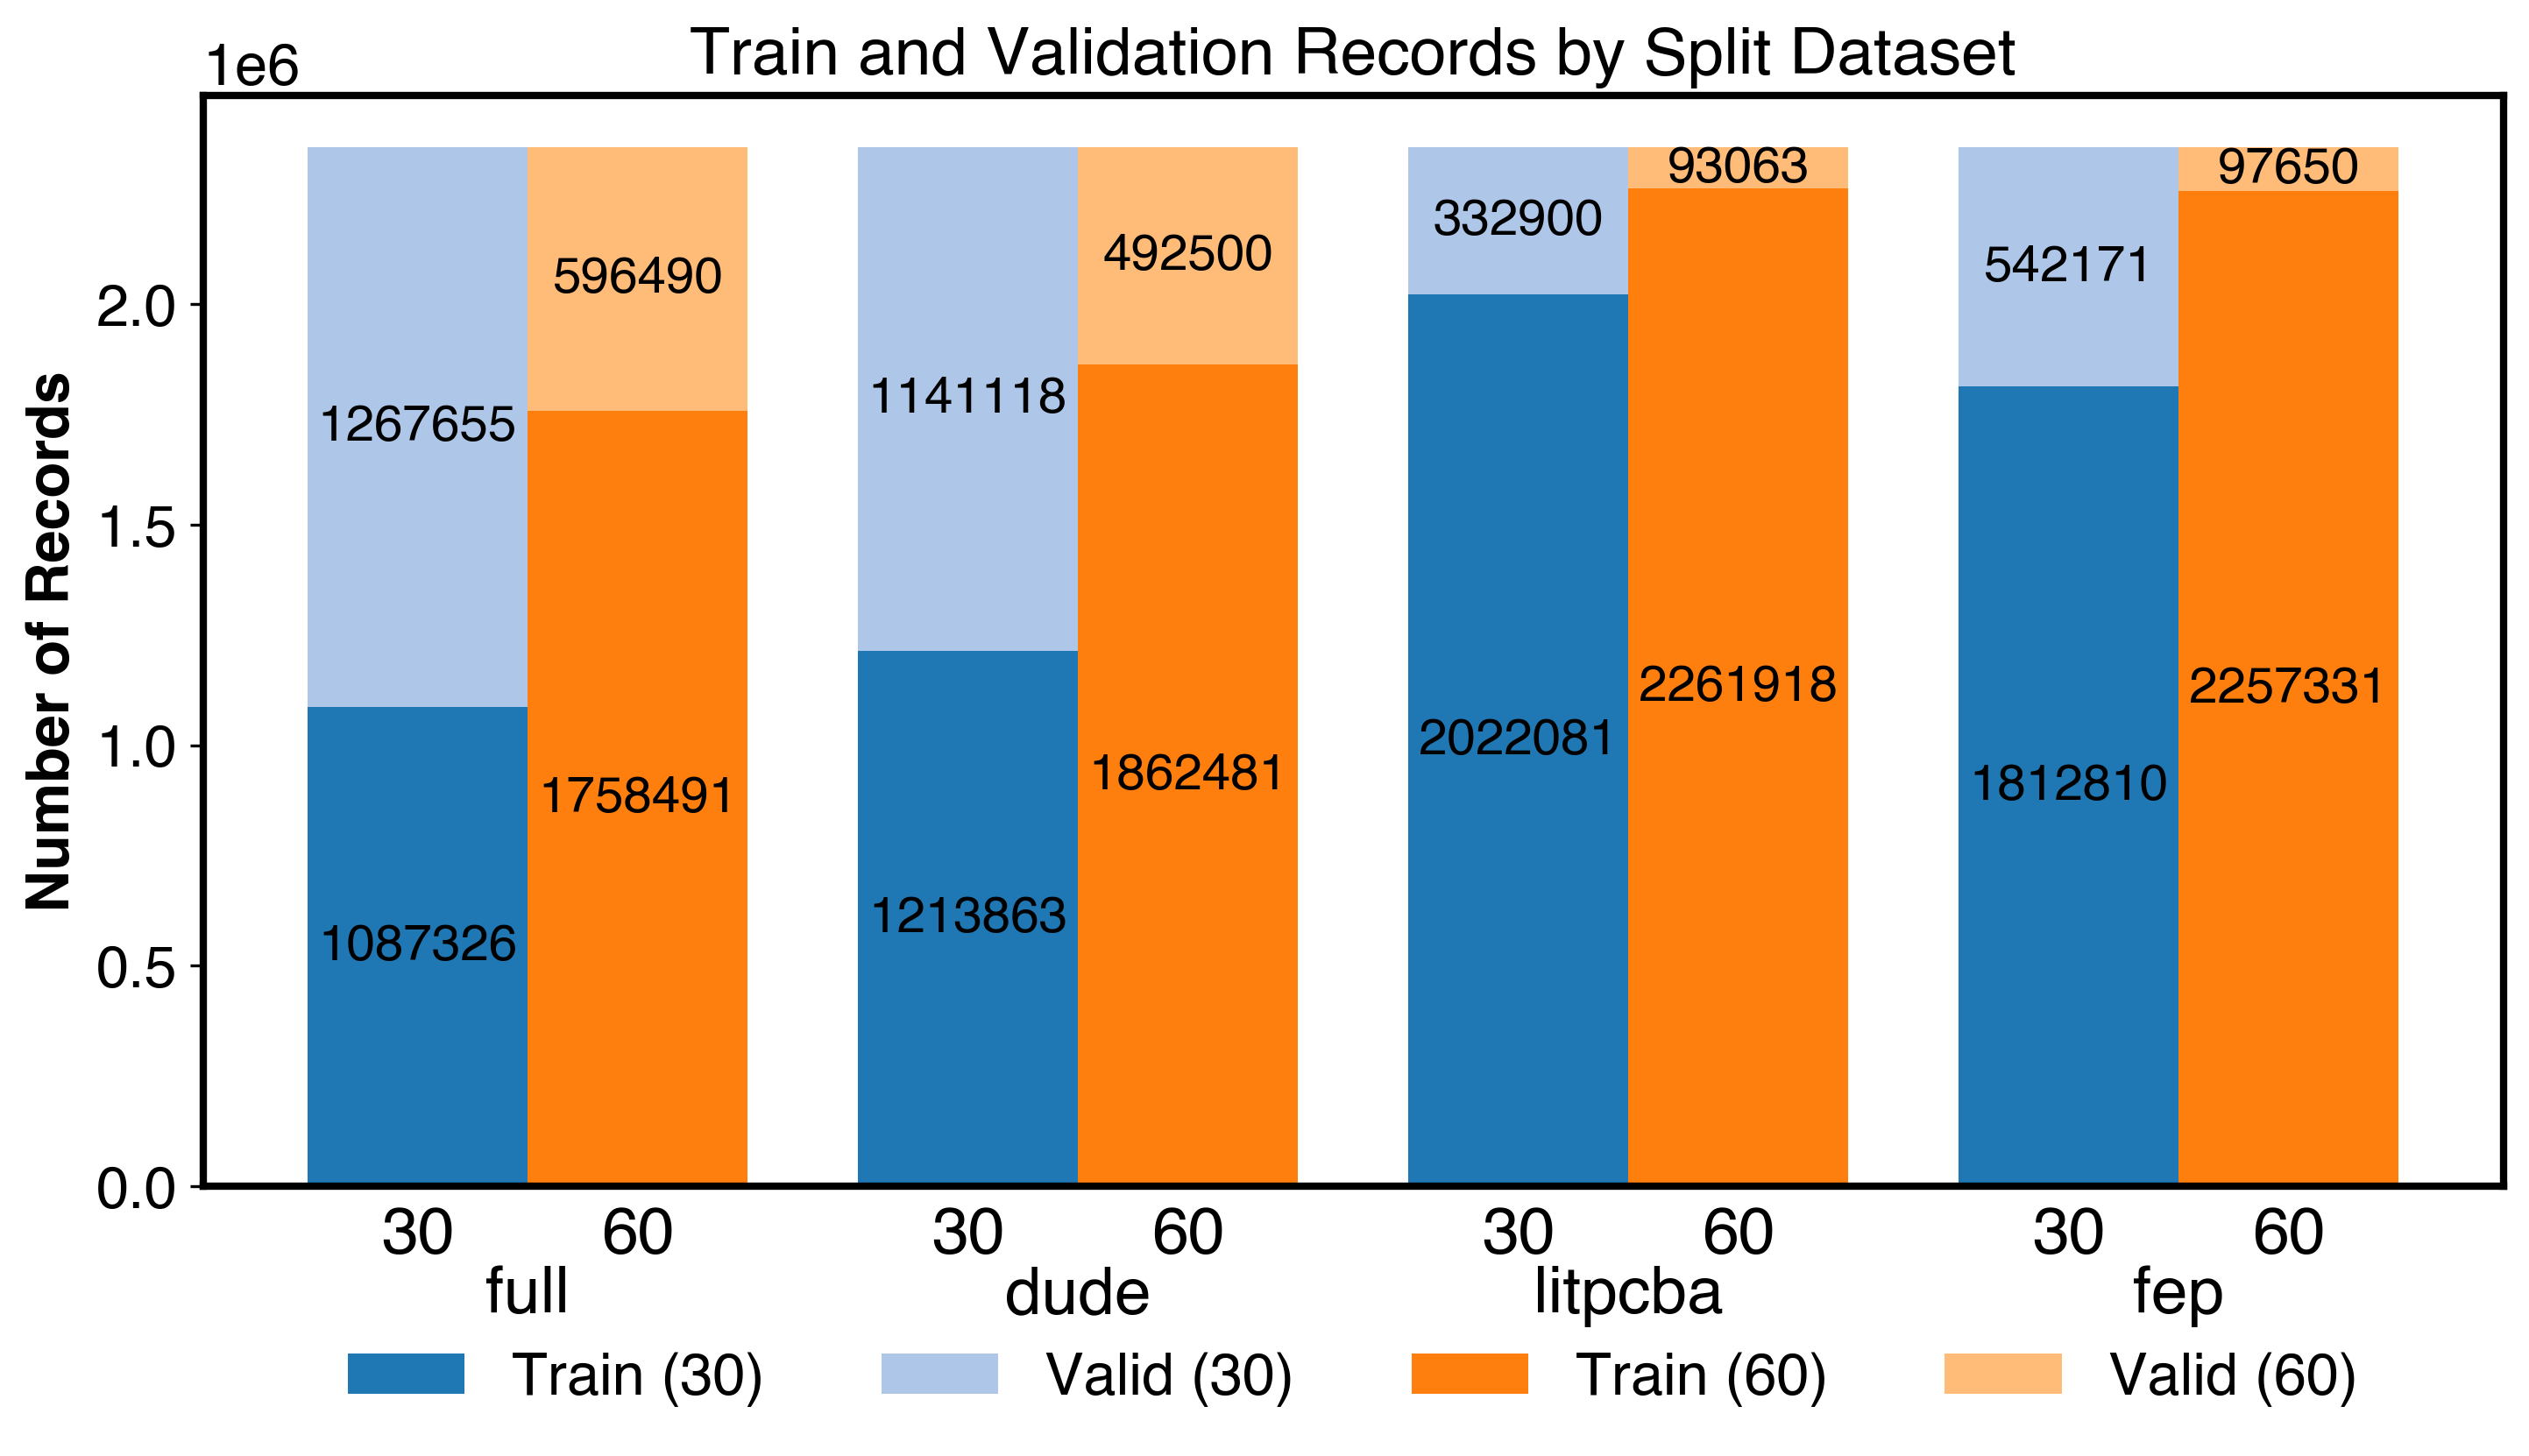

In [46]:
# Collect statistics in a dictionary
statistics = {}
splits = ["full", "dude", "litpcba", "fep"]
for split_name, split_30, split_60 in zip(
    splits, [full_data_split_30, dude_split_30, litpcba_split_30, fep_split_30], 
    [full_data_split_60, dude_split_60, litpcba_split_60, fep_split_60]
):
    train_30, valid_30 = statistics_by_split(split_30, keys_group_by_uniprot)
    train_60, valid_60 = statistics_by_split(split_60, keys_group_by_uniprot)
    statistics[split_name] = {
        "30": {"train": train_30, "valid": valid_30},
        "60": {"train": train_60, "valid": valid_60},
    }

# Plot the results
x = range(len(splits))
width = 0.4

train_30 = [statistics[split]["30"]["train"] for split in splits]
valid_30 = [statistics[split]["30"]["valid"] for split in splits]
train_60 = [statistics[split]["60"]["train"] for split in splits]
valid_60 = [statistics[split]["60"]["valid"] for split in splits]

# Update the bar chart with scientific colors and detailed annotations
fig, ax = plt.subplots(figsize=(10, 6))

# Define scientific colors
train_30_color = "#1f77b4"  # Blue
valid_30_color = "#aec7e8"  # Light Blue
train_60_color = "#ff7f0e"  # Orange
valid_60_color = "#ffbb78"  # Light Orange

# Plot 30 split
rects1 = ax.bar(
    [i - width / 2 for i in x], train_30, width, label="Train (30)", color=train_30_color
)
rects2 = ax.bar(
    [i - width / 2 for i in x], valid_30, width, bottom=train_30, label="Valid (30)", color=valid_30_color
)

# Plot 60 split
rects3 = ax.bar(
    [i + width / 2 for i in x], train_60, width, label="Train (60)", color=train_60_color
)
rects4 = ax.bar(
    [i + width / 2 for i in x], valid_60, width, bottom=train_60, label="Valid (60)", color=valid_60_color
)

# Add detailed numbers on the bars
for rect in rects1 + rects2 + rects3 + rects4:
    height = rect.get_height()
    if height > 0:
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_y() + height / 2,
            f"{int(height)}",
            ha="center",
            va="center",
            fontsize=14,
            color="black"
        )

# Add custom x-axis labels
for i, split in enumerate(splits):
    ax.text(
        i - width / 2, -max(train_30 + valid_30 + train_60 + valid_60) * 0.05,
        "30", ha="center", va="center", color="black"
    )
    ax.text(
        i + width / 2, -max(train_30 + valid_30 + train_60 + valid_60) * 0.05,
        "60", ha="center", va="center", color="black"
    )
    ax.text(
        i, -max(train_30 + valid_30 + train_60 + valid_60) * 0.11,
        split, ha="center", va="center", color="black"
    )

# Add labels and legend
# ax.set_xlabel("Split Dataset")
ax.set_ylabel("Number of Records")
ax.set_title("Train and Validation Records by Split Dataset")
ax.set_xticks([])  # Remove default x-ticks

# Place the legend outside the figure, to the bottom
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4)

plt.tight_layout()
plt.show()


## Assay Statistics

In [4]:
lmdb = LMDBDataset("/data/rerank/protenix/chembl_bdb/chembl_bdb.lmdb")
record_keys = lmdb.get_split("clean_keys_has_feature")
assay_groups = lmdb["assay_groups"]

Number of records: 2354981
Number of assay groups with more than 1 records: 98494 (64.11%)
Number of assay groups with more than 5 records: 60417 (39.32%)
Number of assay groups with more than 10 records: 43654 (28.41%)
Number of assay groups with more than 100 records: 4005 (2.61%)
Number of assay groups with more than 1000 records: 38 (0.02%)


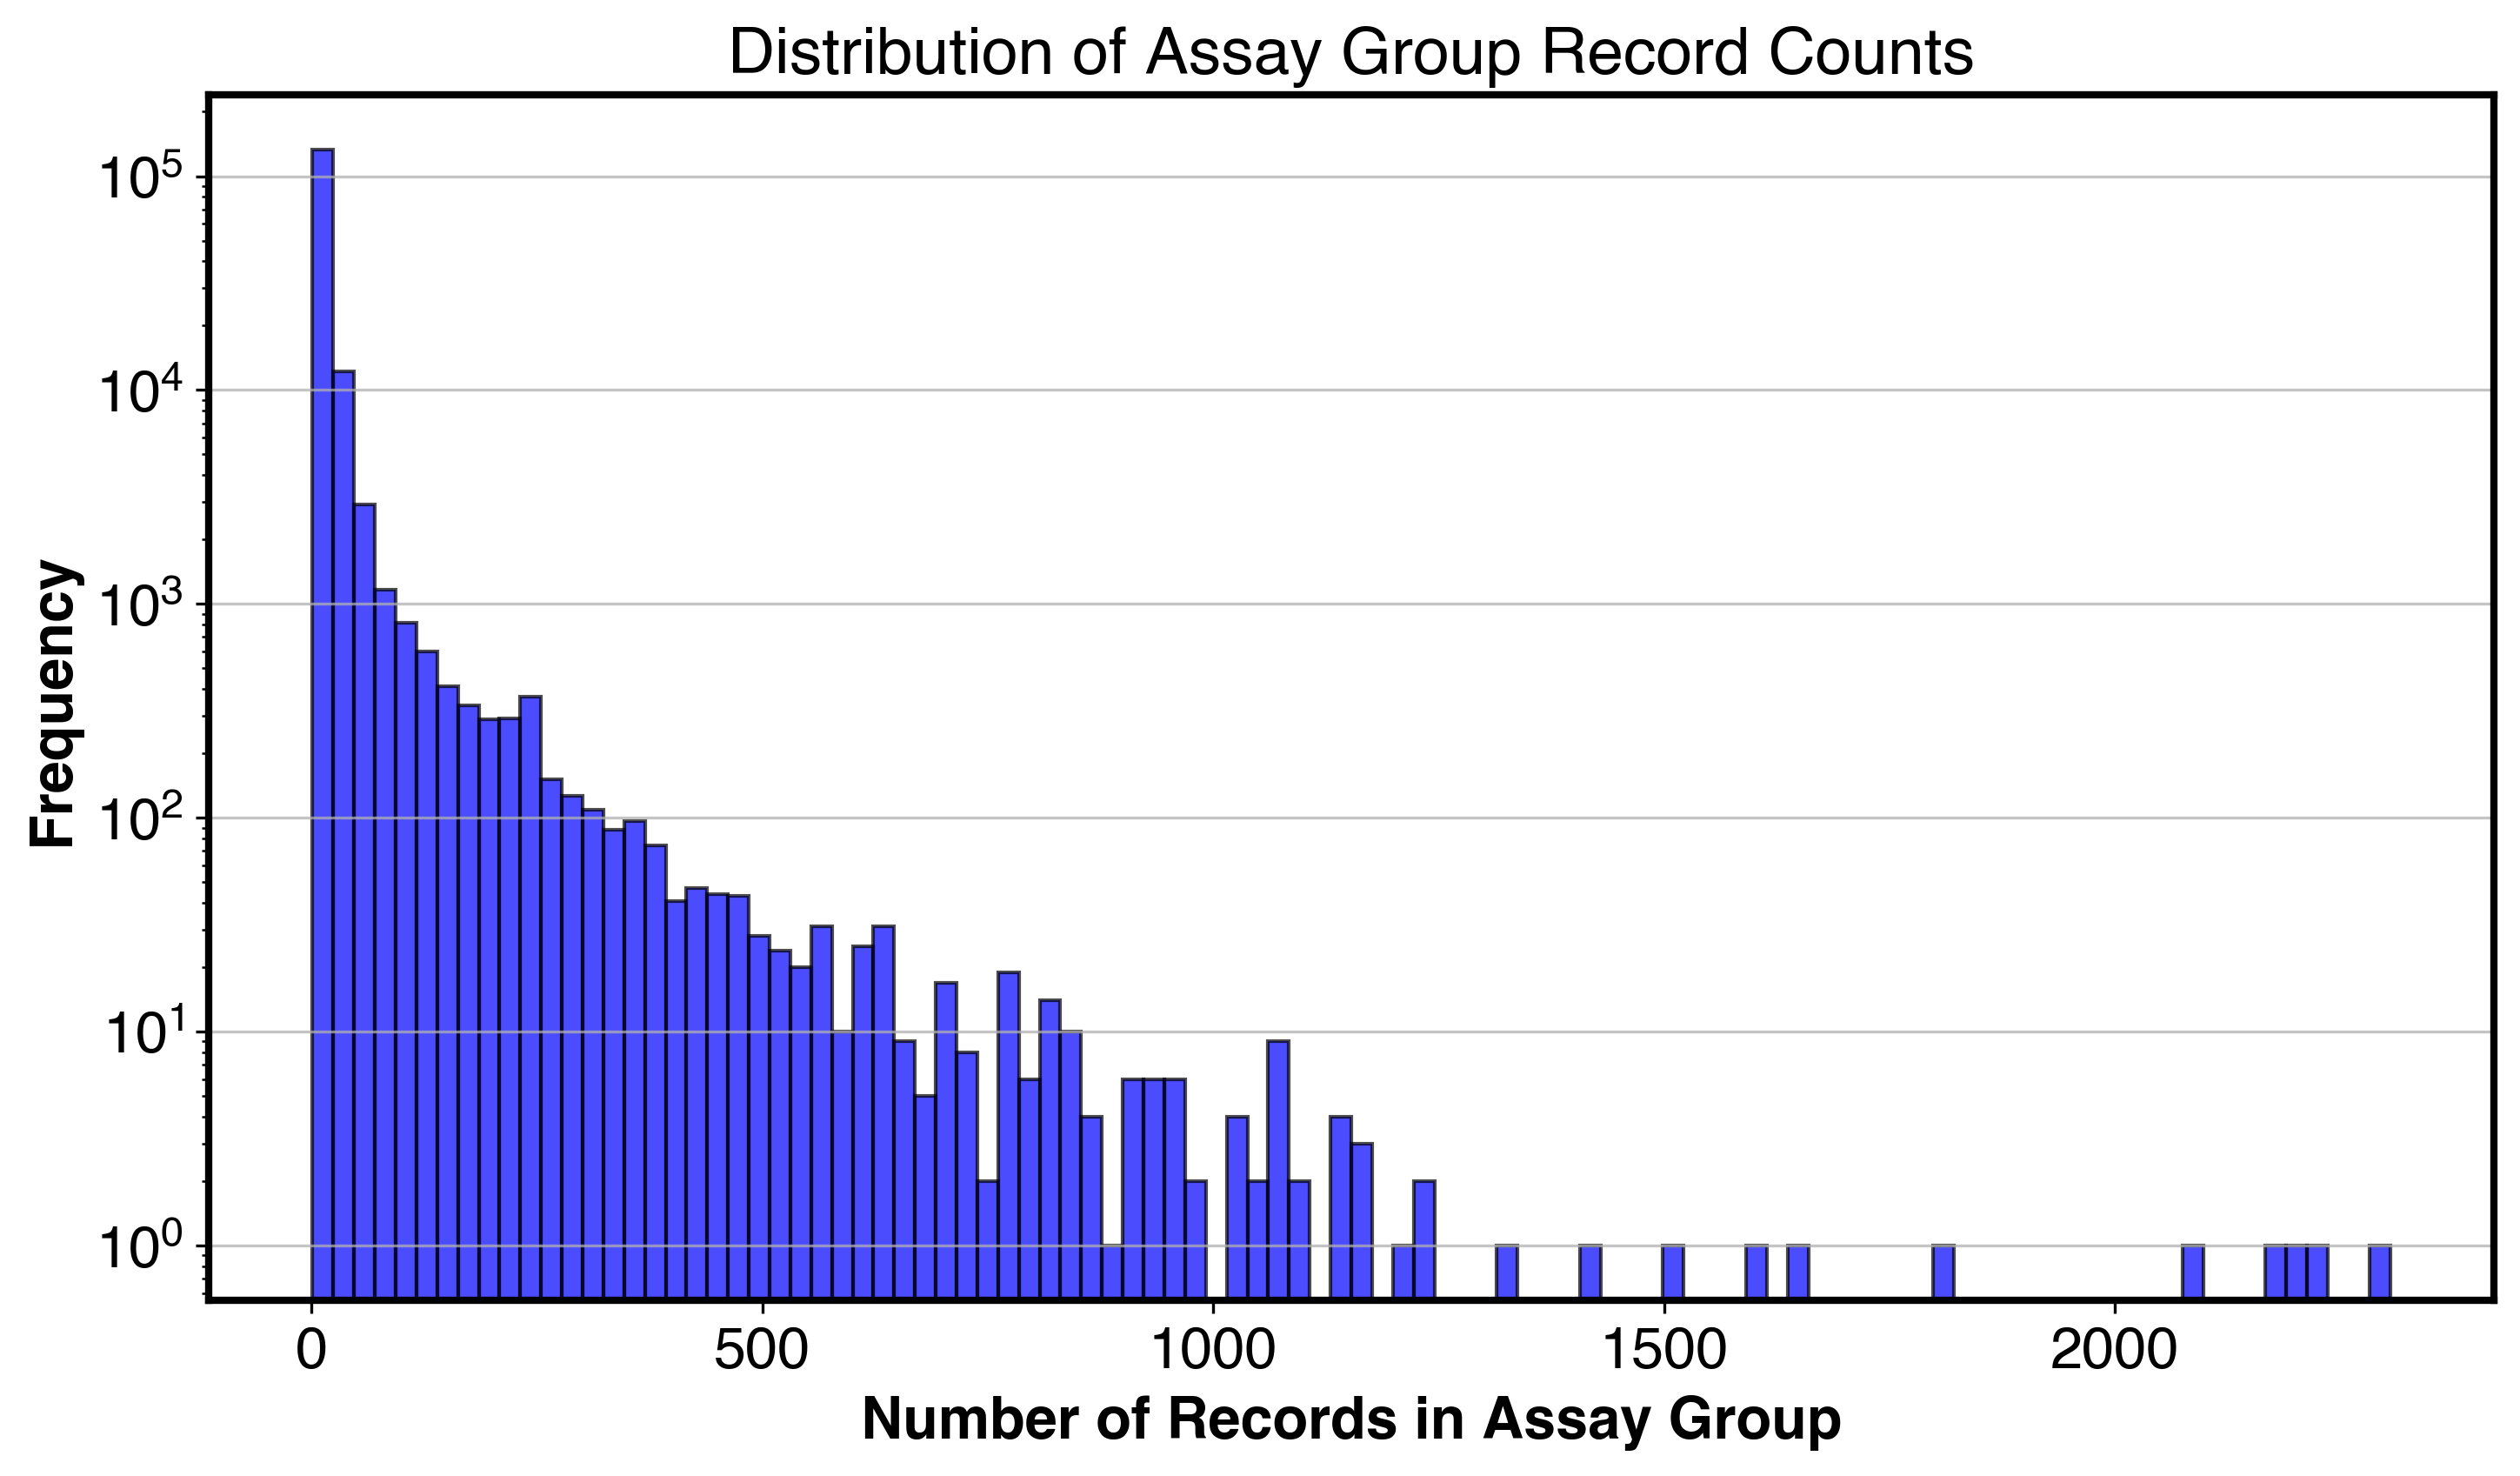

In [20]:
print("Number of records:", len(record_keys))
for threshold in [1, 5, 10, 100, 1000]:
    n_assay_groups = len(
        [k for k in assay_groups.values() if len(k) > threshold]
    )
    ratio = n_assay_groups / len(assay_groups)
    print(
        f"Number of assay groups with more than {threshold} records: "
        f"{n_assay_groups} ({ratio:.2%})"
    )

# plot histogram of record count of assay groups
assay_group_count = {}
for group_key, group in assay_groups.items():
    assay_group_count[group_key] = len(group)
assay_group_count_values = list(assay_group_count.values())
plt.figure(figsize=(10, 6))
plt.hist(
    assay_group_count_values,
    bins=100,
    color="blue",
    alpha=0.7,
    edgecolor="black",
)
plt.xlabel("Number of Records in Assay Group")
plt.ylabel("Frequency")
plt.title("Distribution of Assay Group Record Counts")
plt.yscale("log")
plt.grid(axis="y", alpha=0.75)
plt.tight_layout()
plt.show()

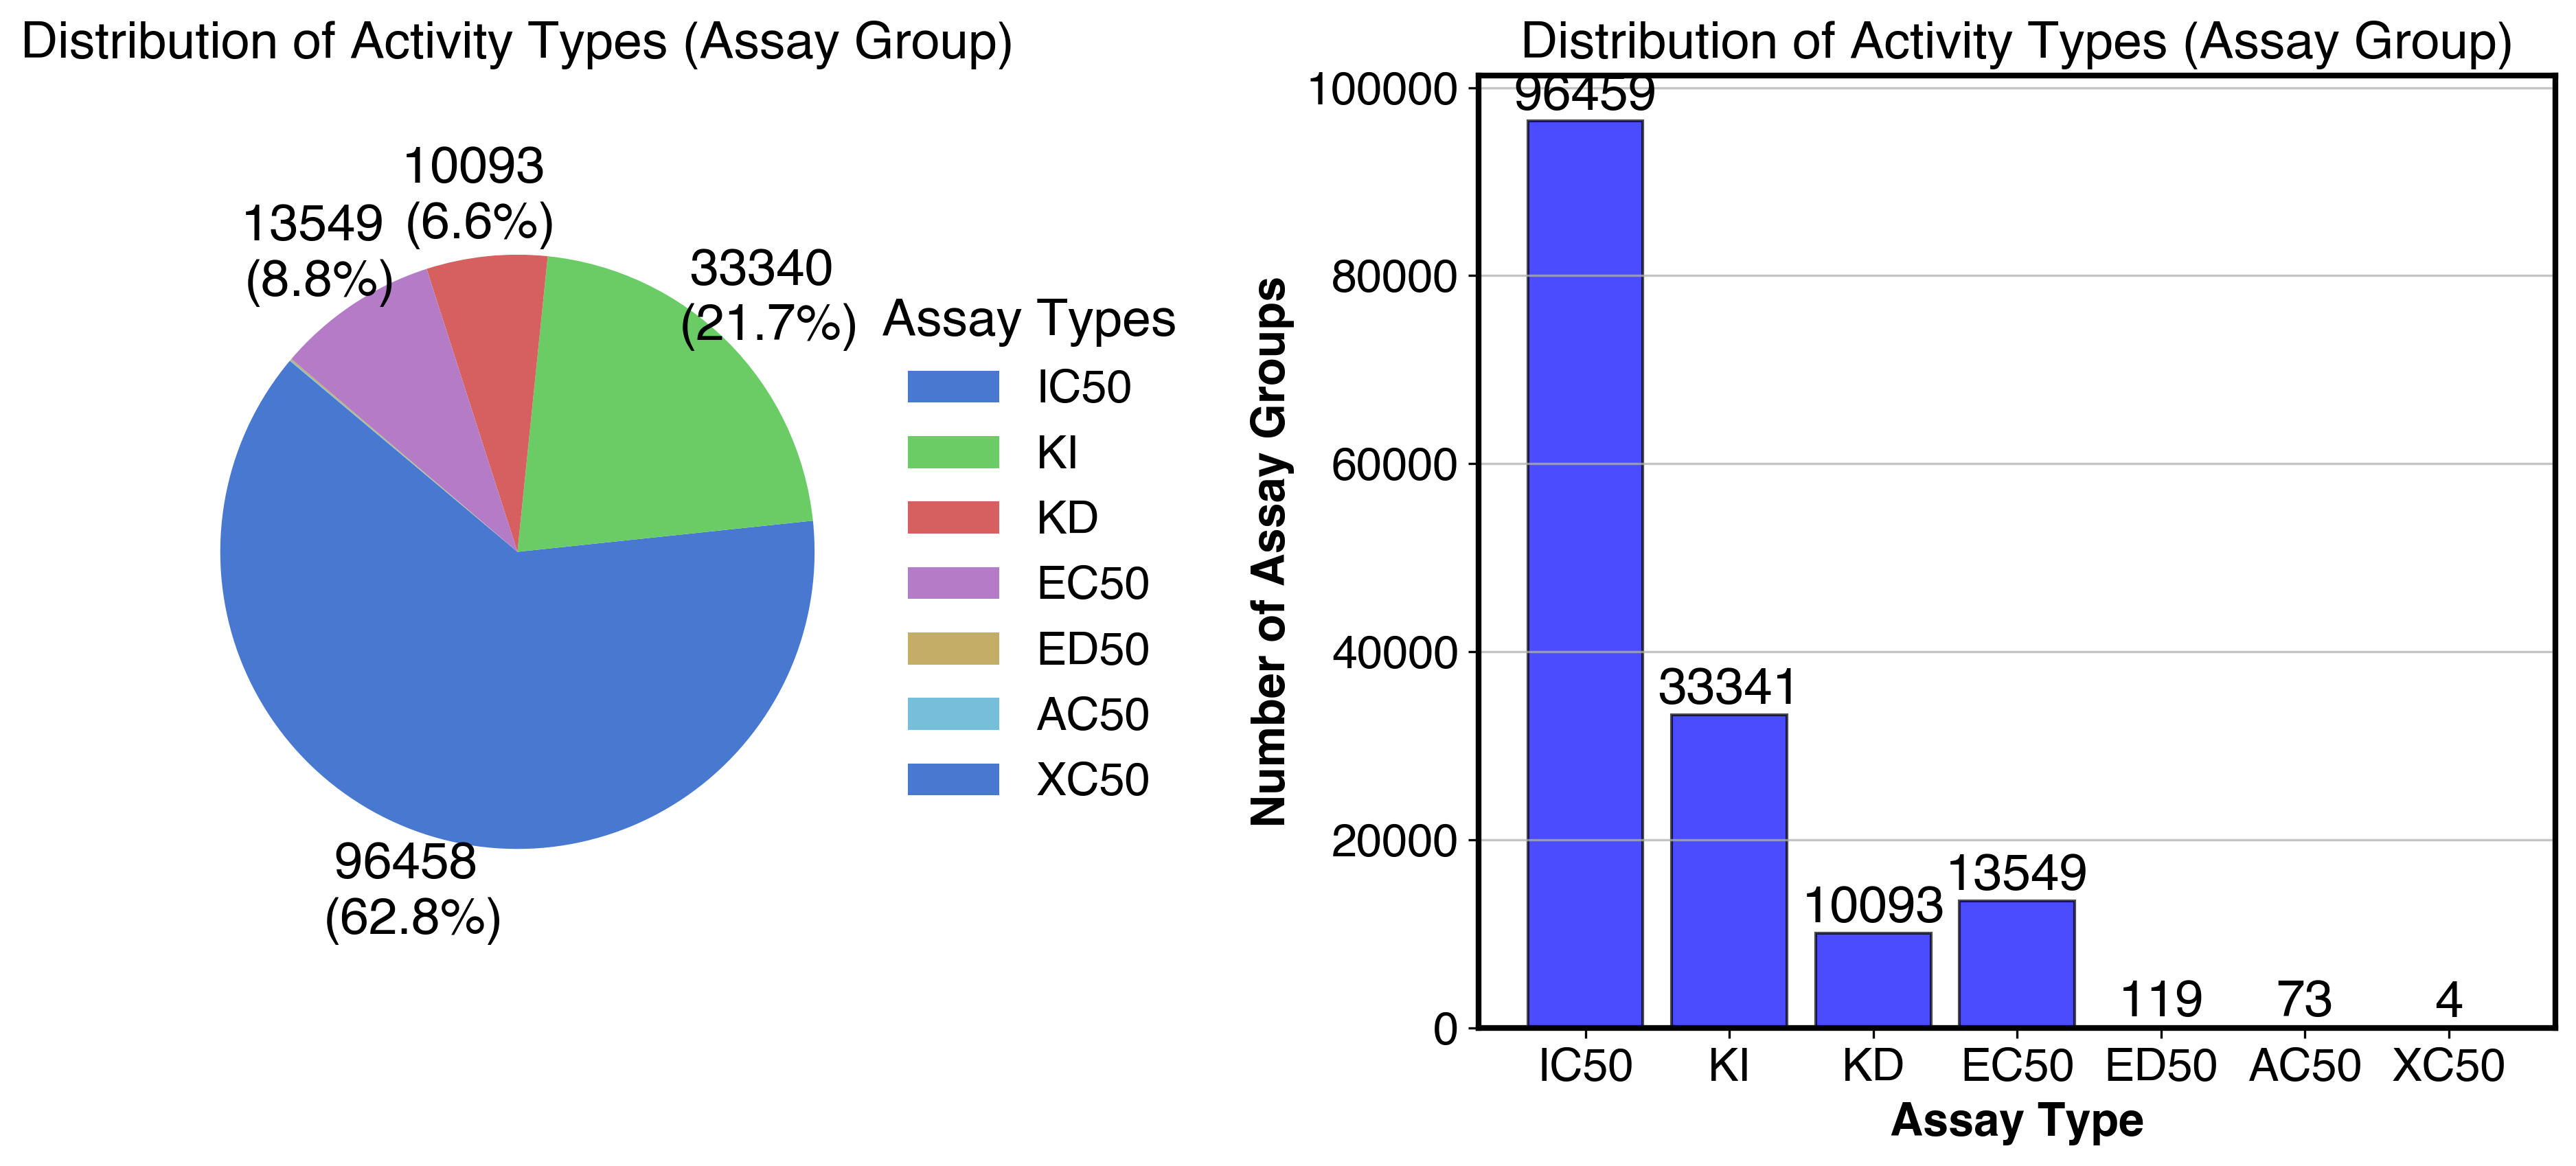

In [73]:
# count assay type for each group
assay_type_count = {}
for group_key, group in assay_groups.items():
    assay_type = group_key.split("_")[-1]
    if assay_type not in assay_type_count:
        assay_type_count[assay_type] = 0
    assay_type_count[assay_type] += 1

# Combine pie chart and histogram into one figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), width_ratios=[1.5, 2.5])

# Plot pie chart of assay type count on the left
wedges, texts, autotexts = axes[0].pie(
    assay_type_count.values(),
    labels=None,  # Remove labels from the pie chart
    autopct=lambda pct: (
        f"{int(pct / 100 * sum(assay_type_count.values()))} \n({pct:.1f}%)"
        if pct > 1
        else ""
    ),
    startangle=140,
    textprops=dict(color="black"),
    pctdistance=1.2,
)
axes[0].axis(
    "equal"
)  # Equal aspect ratio ensures that pie is drawn as a circle.
axes[0].set_title("Distribution of Activity Types (Assay Group)")

# Add a legend for the pie chart
axes[0].legend(
    wedges,
    assay_type_count.keys(),
    title="Assay Types",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
)


# Plot bar chart of assay type count on the right
bars = axes[1].bar(
    assay_type_count.keys(),
    assay_type_count.values(),
    color="blue",
    alpha=0.7,
    edgecolor="black",
)
axes[1].set_xlabel("Assay Type")
axes[1].set_ylabel("Number of Assay Groups")
axes[1].set_title("Distribution of Activity Types (Assay Group)")
axes[1].grid(axis="y", alpha=0.75)

# Add annotations to the bar chart
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        # fontsize=10,
        color="black",
    )

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

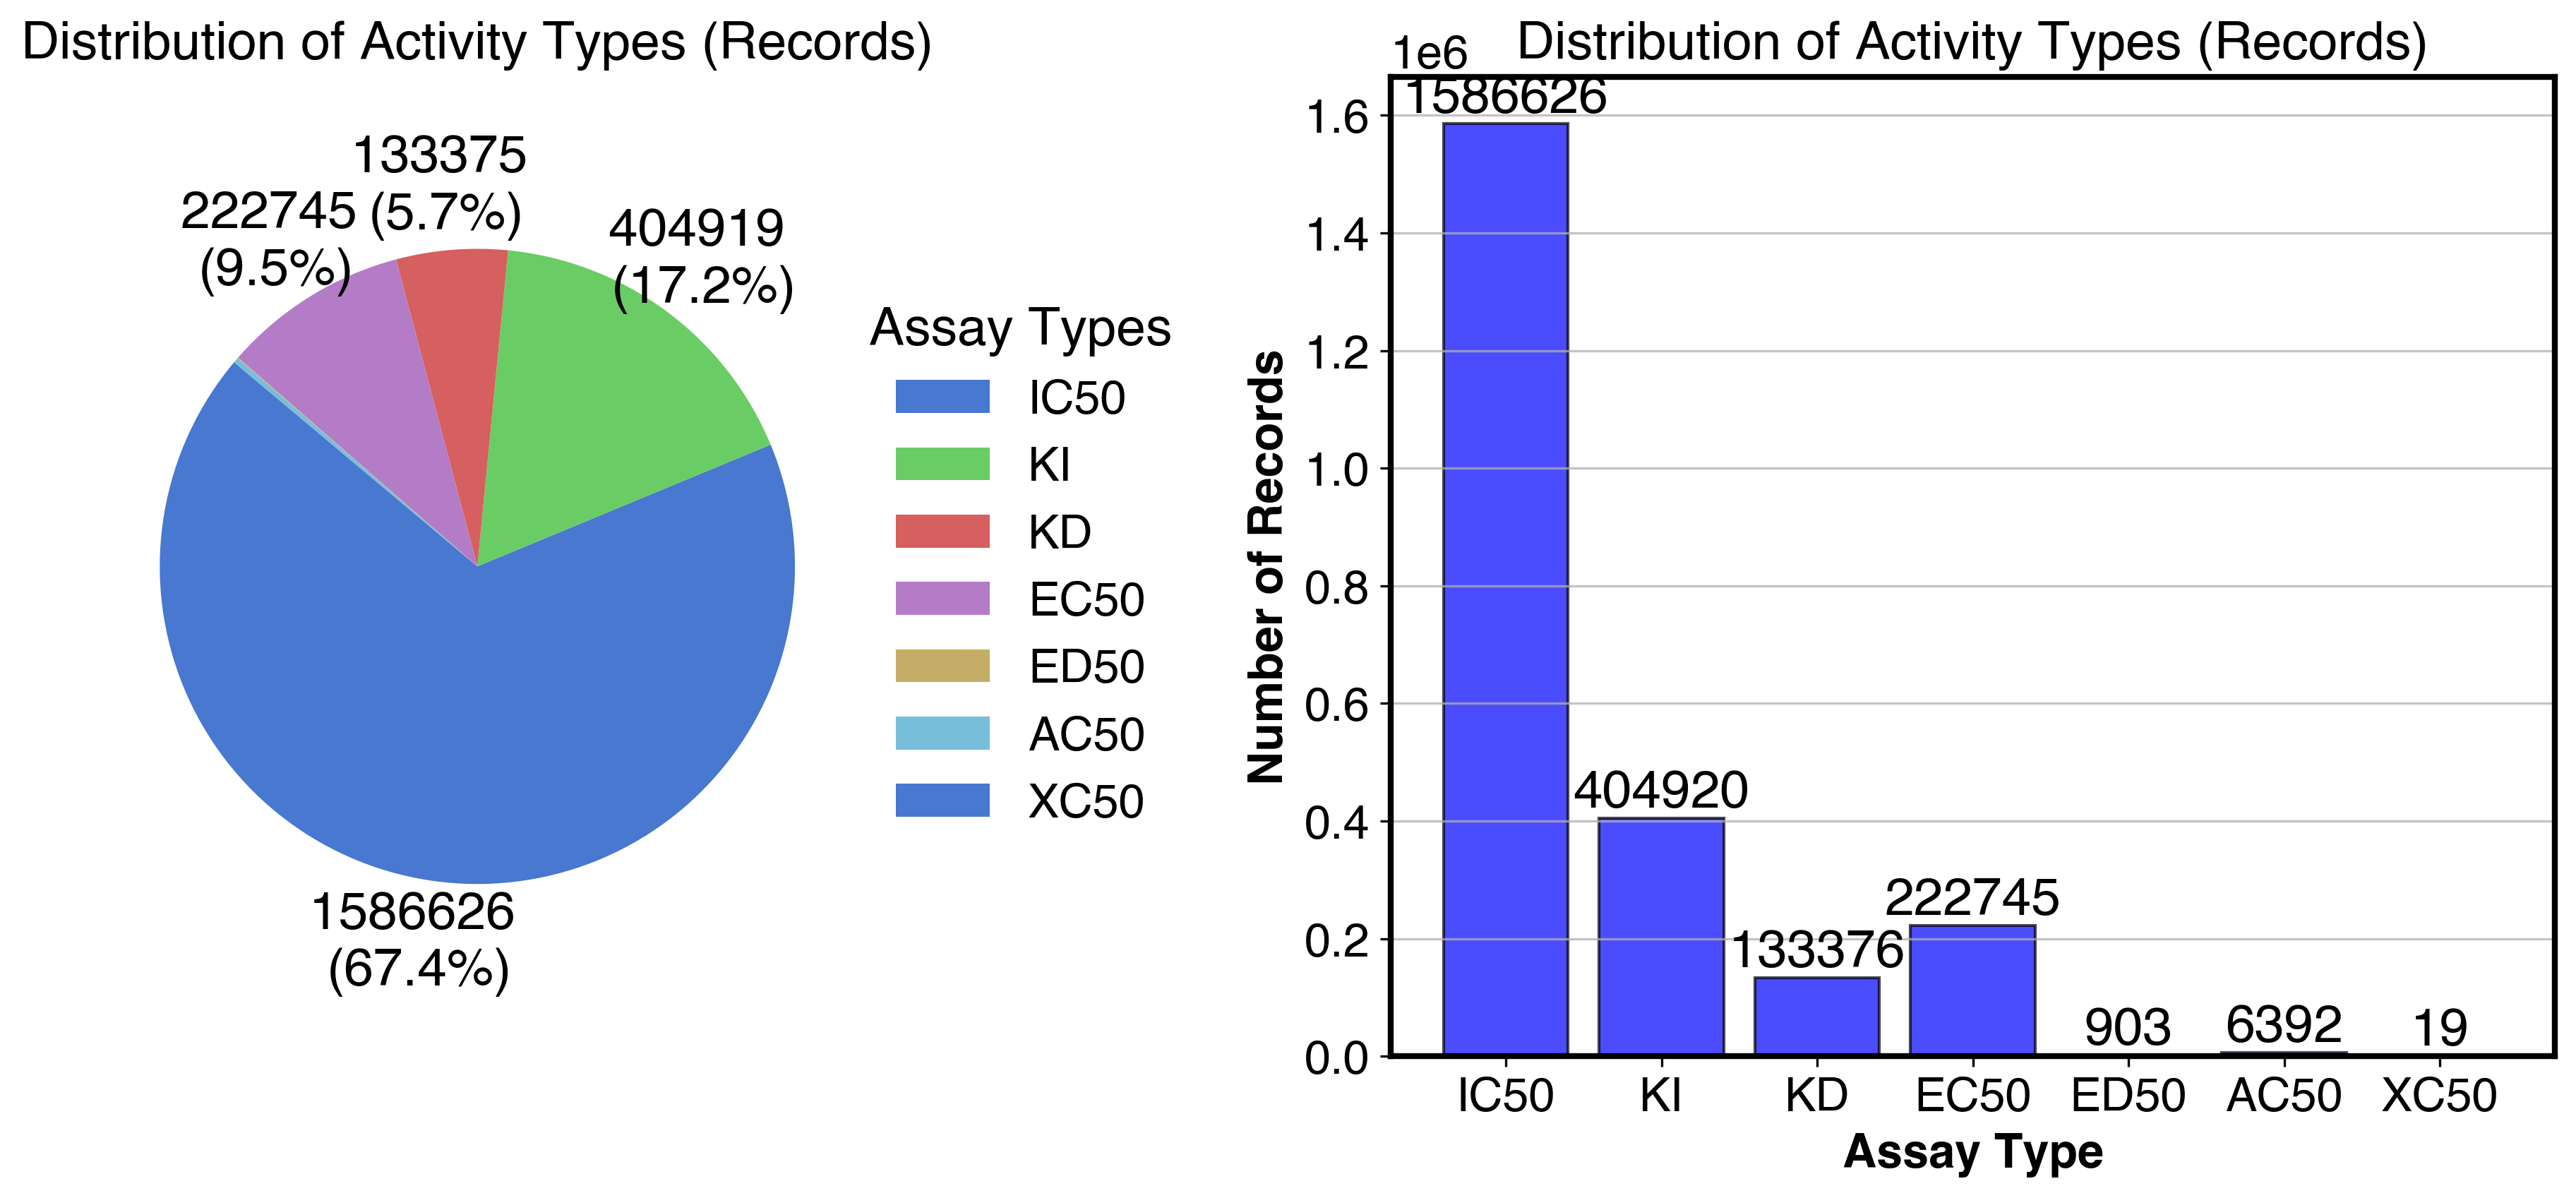

In [70]:
# count assay type for each group
assay_type_count = {}
for group_key, group in assay_groups.items():
    assay_type = group_key.split("_")[-1]
    if assay_type not in assay_type_count:
        assay_type_count[assay_type] = 0
    assay_type_count[assay_type] += len(group)

# Combine pie chart and histogram into one figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), width_ratios=[1.5, 2.5])

# Plot pie chart of assay type count on the left
wedges, texts, autotexts = axes[0].pie(
    assay_type_count.values(),
    labels=None,  # Remove labels from the pie chart
    autopct=lambda pct: (
        f"{int(pct / 100 * sum(assay_type_count.values()))} \n({pct:.1f}%)"
        if pct > 1
        else ""
    ),
    startangle=140,
    textprops=dict(color="black"),
    pctdistance=1.2,
)
axes[0].axis(
    "equal"
)  # Equal aspect ratio ensures that pie is drawn as a circle.
axes[0].set_title("Distribution of Activity Types (Records)")

# Add a legend for the pie chart
axes[0].legend(
    wedges,
    assay_type_count.keys(),
    title="Assay Types",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
)

# Plot bar chart of assay type count on the right
bars = axes[1].bar(
    assay_type_count.keys(),
    assay_type_count.values(),
    color="blue",
    alpha=0.7,
    edgecolor="black",
)
axes[1].set_xlabel("Assay Type")
axes[1].set_ylabel("Number of Records")
axes[1].set_title("Distribution of Activity Types (Records)")
axes[1].grid(axis="y", alpha=0.75)

# Add annotations to the bar chart
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        # fontsize=10,
        color="black",
    )

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [19]:
lmdb = LMDBDataset("/data/rerank/protenix/chembl_bdb/chembl_bdb.lmdb")
assay_pairs = lmdb["assay_pairs"]
len(assay_pairs)

67645

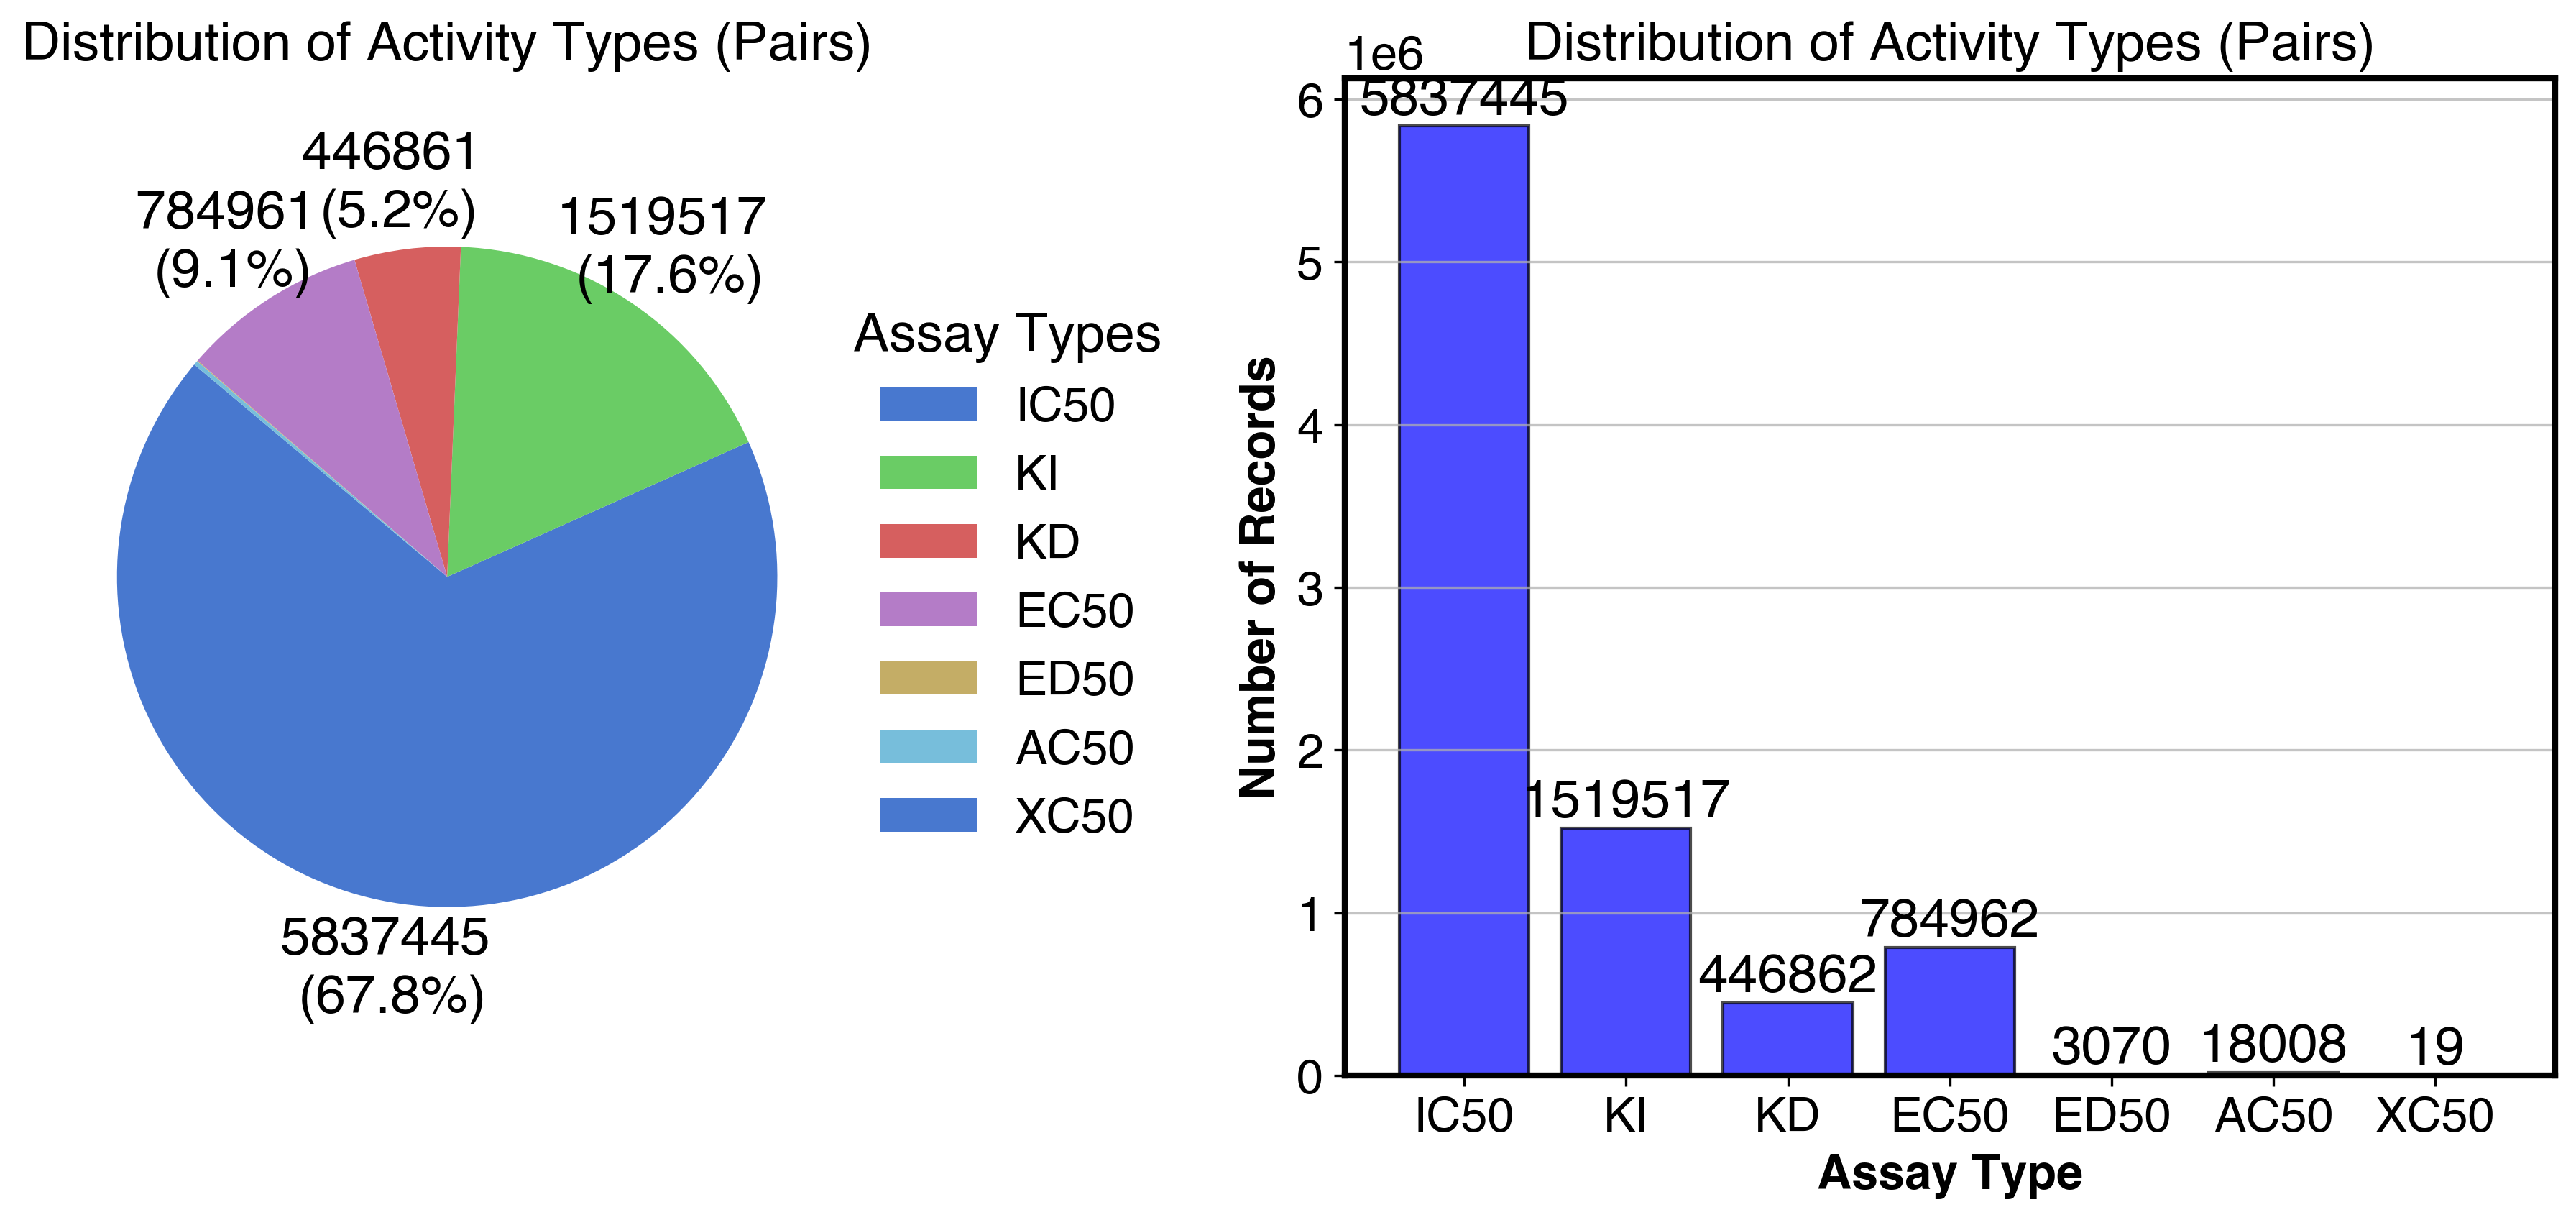

In [117]:
# count assay type for each group
assay_type_count = {}
for group_key, group in assay_pairs.items():
    assay_type = group_key.split("_")[-1]
    if assay_type not in assay_type_count:
        assay_type_count[assay_type] = 0
    assay_type_count[assay_type] += min(len(group), 1000)

# Combine pie chart and histogram into one figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), width_ratios=[1.5, 2.5])

# Plot pie chart of assay type count on the left
wedges, texts, autotexts = axes[0].pie(
    assay_type_count.values(),
    labels=None,  # Remove labels from the pie chart
    autopct=lambda pct: (
        f"{int(pct / 100 * sum(assay_type_count.values()))} \n({pct:.1f}%)"
        if pct > 1
        else ""
    ),
    startangle=140,
    textprops=dict(color="black"),
    pctdistance=1.2,
)
axes[0].axis(
    "equal"
)  # Equal aspect ratio ensures that pie is drawn as a circle.
axes[0].set_title("Distribution of Activity Types (Pairs)")

# Add a legend for the pie chart
axes[0].legend(
    wedges,
    assay_type_count.keys(),
    title="Assay Types",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
)

# Plot bar chart of assay type count on the right
bars = axes[1].bar(
    assay_type_count.keys(),
    assay_type_count.values(),
    color="blue",
    alpha=0.7,
    edgecolor="black",
)
axes[1].set_xlabel("Assay Type")
axes[1].set_ylabel("Number of Records")
axes[1].set_title("Distribution of Activity Types (Pairs)")
axes[1].grid(axis="y", alpha=0.75)

# Add annotations to the bar chart
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        # fontsize=10,
        color="black",
    )

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [21]:
def pairs_statistics_by_split(
    data_split, pairs_group_by_assays, max_pairs_to_count=1000
):
    train_uniprotids = set(data_split["train"])
    valid_uniprotids = set(data_split["valid"])
    total_train_keys = 0
    total_valid_keys = 0
    for assay_group_key, pairs in pairs_group_by_assays.items():
        uniprot_id = assay_group_key.split("_")[2]
        if uniprot_id in train_uniprotids:
            total_train_keys += min(len(pairs), max_pairs_to_count)
        elif uniprot_id in valid_uniprotids:
            total_valid_keys += min(len(pairs), max_pairs_to_count)
    return total_train_keys, total_valid_keys

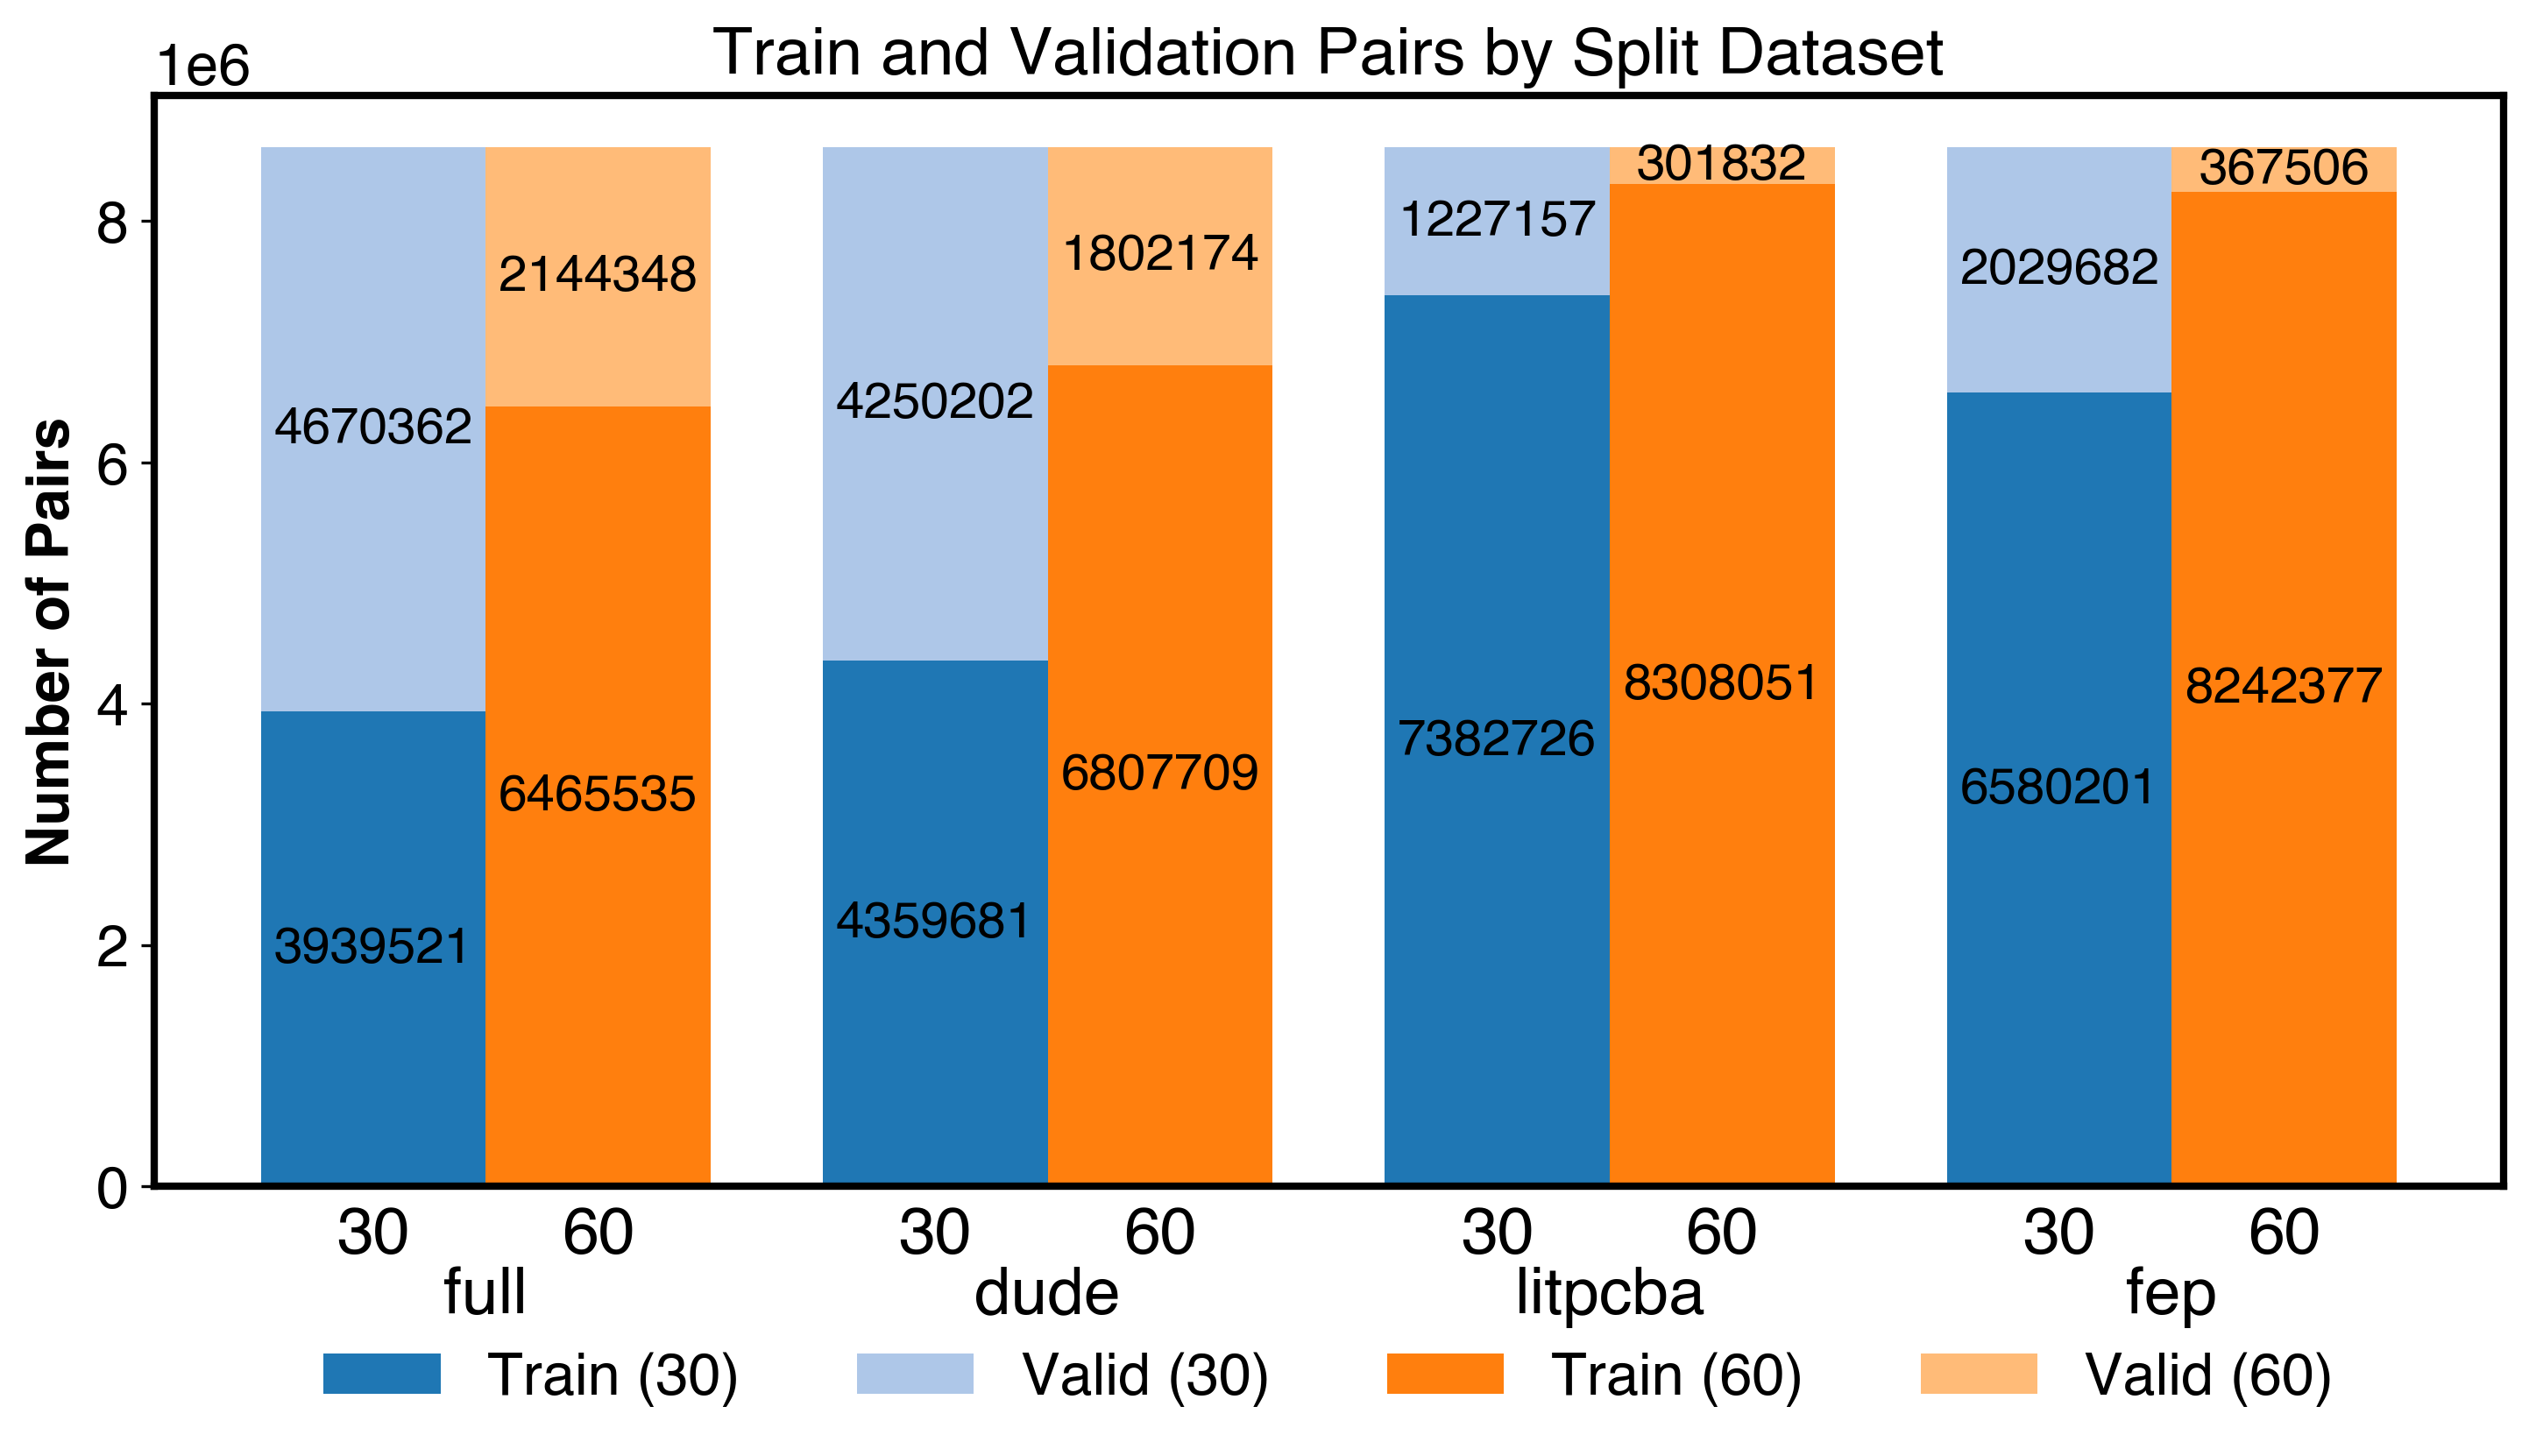

In [130]:
# Collect statistics in a dictionary
statistics = {}
splits = ["full", "dude", "litpcba", "fep"]
for split_name, split_30, split_60 in zip(
    splits,
    [full_data_split_30, dude_split_30, litpcba_split_30, fep_split_30],
    [full_data_split_60, dude_split_60, litpcba_split_60, fep_split_60],
):
    train_30, valid_30 = pairs_statistics_by_split(split_30, assay_pairs)
    train_60, valid_60 = pairs_statistics_by_split(split_60, assay_pairs)
    statistics[split_name] = {
        "30": {"train": train_30, "valid": valid_30},
        "60": {"train": train_60, "valid": valid_60},
    }

# Plot the results
x = range(len(splits))
width = 0.4

train_30 = [statistics[split]["30"]["train"] for split in splits]
valid_30 = [statistics[split]["30"]["valid"] for split in splits]
train_60 = [statistics[split]["60"]["train"] for split in splits]
valid_60 = [statistics[split]["60"]["valid"] for split in splits]

# Update the bar chart with scientific colors and detailed annotations
fig, ax = plt.subplots(figsize=(10, 6))

# Define scientific colors
train_30_color = "#1f77b4"  # Blue
valid_30_color = "#aec7e8"  # Light Blue
train_60_color = "#ff7f0e"  # Orange
valid_60_color = "#ffbb78"  # Light Orange

# Plot 30 split
rects1 = ax.bar(
    [i - width / 2 for i in x],
    train_30,
    width,
    label="Train (30)",
    color=train_30_color,
)
rects2 = ax.bar(
    [i - width / 2 for i in x],
    valid_30,
    width,
    bottom=train_30,
    label="Valid (30)",
    color=valid_30_color,
)

# Plot 60 split
rects3 = ax.bar(
    [i + width / 2 for i in x],
    train_60,
    width,
    label="Train (60)",
    color=train_60_color,
)
rects4 = ax.bar(
    [i + width / 2 for i in x],
    valid_60,
    width,
    bottom=train_60,
    label="Valid (60)",
    color=valid_60_color,
)

# Add detailed numbers on the bars
for rect in rects1 + rects2 + rects3 + rects4:
    height = rect.get_height()
    if height > 0:
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_y() + height / 2,
            f"{int(height)}",
            ha="center",
            va="center",
            fontsize=14,
            color="black",
        )

# Add custom x-axis labels
for i, split in enumerate(splits):
    ax.text(
        i - width / 2,
        -max(train_30 + valid_30 + train_60 + valid_60) * 0.05,
        "30",
        ha="center",
        va="center",
        color="black",
    )
    ax.text(
        i + width / 2,
        -max(train_30 + valid_30 + train_60 + valid_60) * 0.05,
        "60",
        ha="center",
        va="center",
        color="black",
    )
    ax.text(
        i,
        -max(train_30 + valid_30 + train_60 + valid_60) * 0.11,
        split,
        ha="center",
        va="center",
        color="black",
    )

# Add labels and legend
# ax.set_xlabel("Split Dataset")
ax.set_ylabel("Number of Pairs")
ax.set_title("Train and Validation Pairs by Split Dataset")
ax.set_xticks([])  # Remove default x-ticks

# Place the legend outside the figure, to the bottom
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4)

plt.tight_layout()
plt.show()

In [7]:
lmdb["A0A024AXB9_012e700815b0e79a293011c56ca11b43"]

{'name': 'A0A024AXB9_012e700815b0e79a293011c56ca11b43',
 'assay_id': 'CHEMBL4825419',
 'uniprot_id': 'A0A024AXB9',
 'source': 'ChEMBL',
 'journal': 'Bioorg Med Chem',
 'patent': '',
 'sequences': [{'proteinChain': {'sequence': 'AETDEDHAHWLEARMLLDNIYLQDGLIASLYRPEADKVAAIEGEFKLRTEQRKTFVELMKRGDLPV',
    'count': 1,
    'msa': {'precomputed_msa_dir': '/data/rerank/protenix/chembl_bdb/precomputed_msa/A0A024AXB9',
     'pairing_db': 'uniref100'}}},
  {'ligand': {'ligand': 'O=C(Nc1ccccc1)[C@@H]1CCCN1C(=O)c1cc2cc(O)c(O)cc2s1',
    'count': 1}}],
 'activity': {'type': 'IC50', 'relation': '=', 'value': 3430.0, 'units': 'nM'},
 'assay_group': 'group_CHEMBL4825419_A0A024AXB9_IC50',
 'len': {'protein': 66, 'ligand': 27}}

In [27]:
print("assay whose protein len < 1024")
assay_below_1024 = {}
for name, assay in assay_groups.items():
    if len(assay) > 0:
        data = lmdb[assay[0]['name']]
        if data["len"]["protein"] < 1024:
            assay_below_1024[name] = assay
print(f"before filter: {len(assay_groups)}")
print(f"after filter: {len(assay_below_1024)}")

assay whose protein len < 1024
before filter: 153638
after filter: 125472


In [18]:
print("30 identity filter")
with open("../scripts/split/splits/chembl_bdb.dude_litpcba_fep.30.json") as f:
    full_data_split_30 = json.load(f)
assay_30_train = {}
assay_30_valid = {}
for name, assay in assay_below_1024.items():
    uniprot_id = name.split("_")[-2]
    if uniprot_id in full_data_split_30["train"]:
        assay_30_train[name] = assay
    elif uniprot_id in full_data_split_30["valid"]:
        assay_30_valid[name] = assay
    else:
        print(f"uniprot id {uniprot_id} not in train or valid")
print(f"train: {len(assay_30_train)}")
print(f"valid: {len(assay_30_valid)}")

30 identity filter
train: 51544
valid: 73928


In [ ]:
assay_pairs_30_train = {}
assay_pairs_30_valid = {}
assay_pairs_filtered = {}
for key in assay_30_train:
    if key in assay_pairs:
        assay_pairs_30_train[key] = assay_pairs[key]
        assay_pairs_filtered[key] = assay_pairs[key]
for key in assay_30_valid:
    if key in assay_pairs:
        assay_pairs_30_valid[key] = assay_pairs[key]
        assay_pairs_filtered[key] = assay_pairs[key]

assay after 1024 len filter


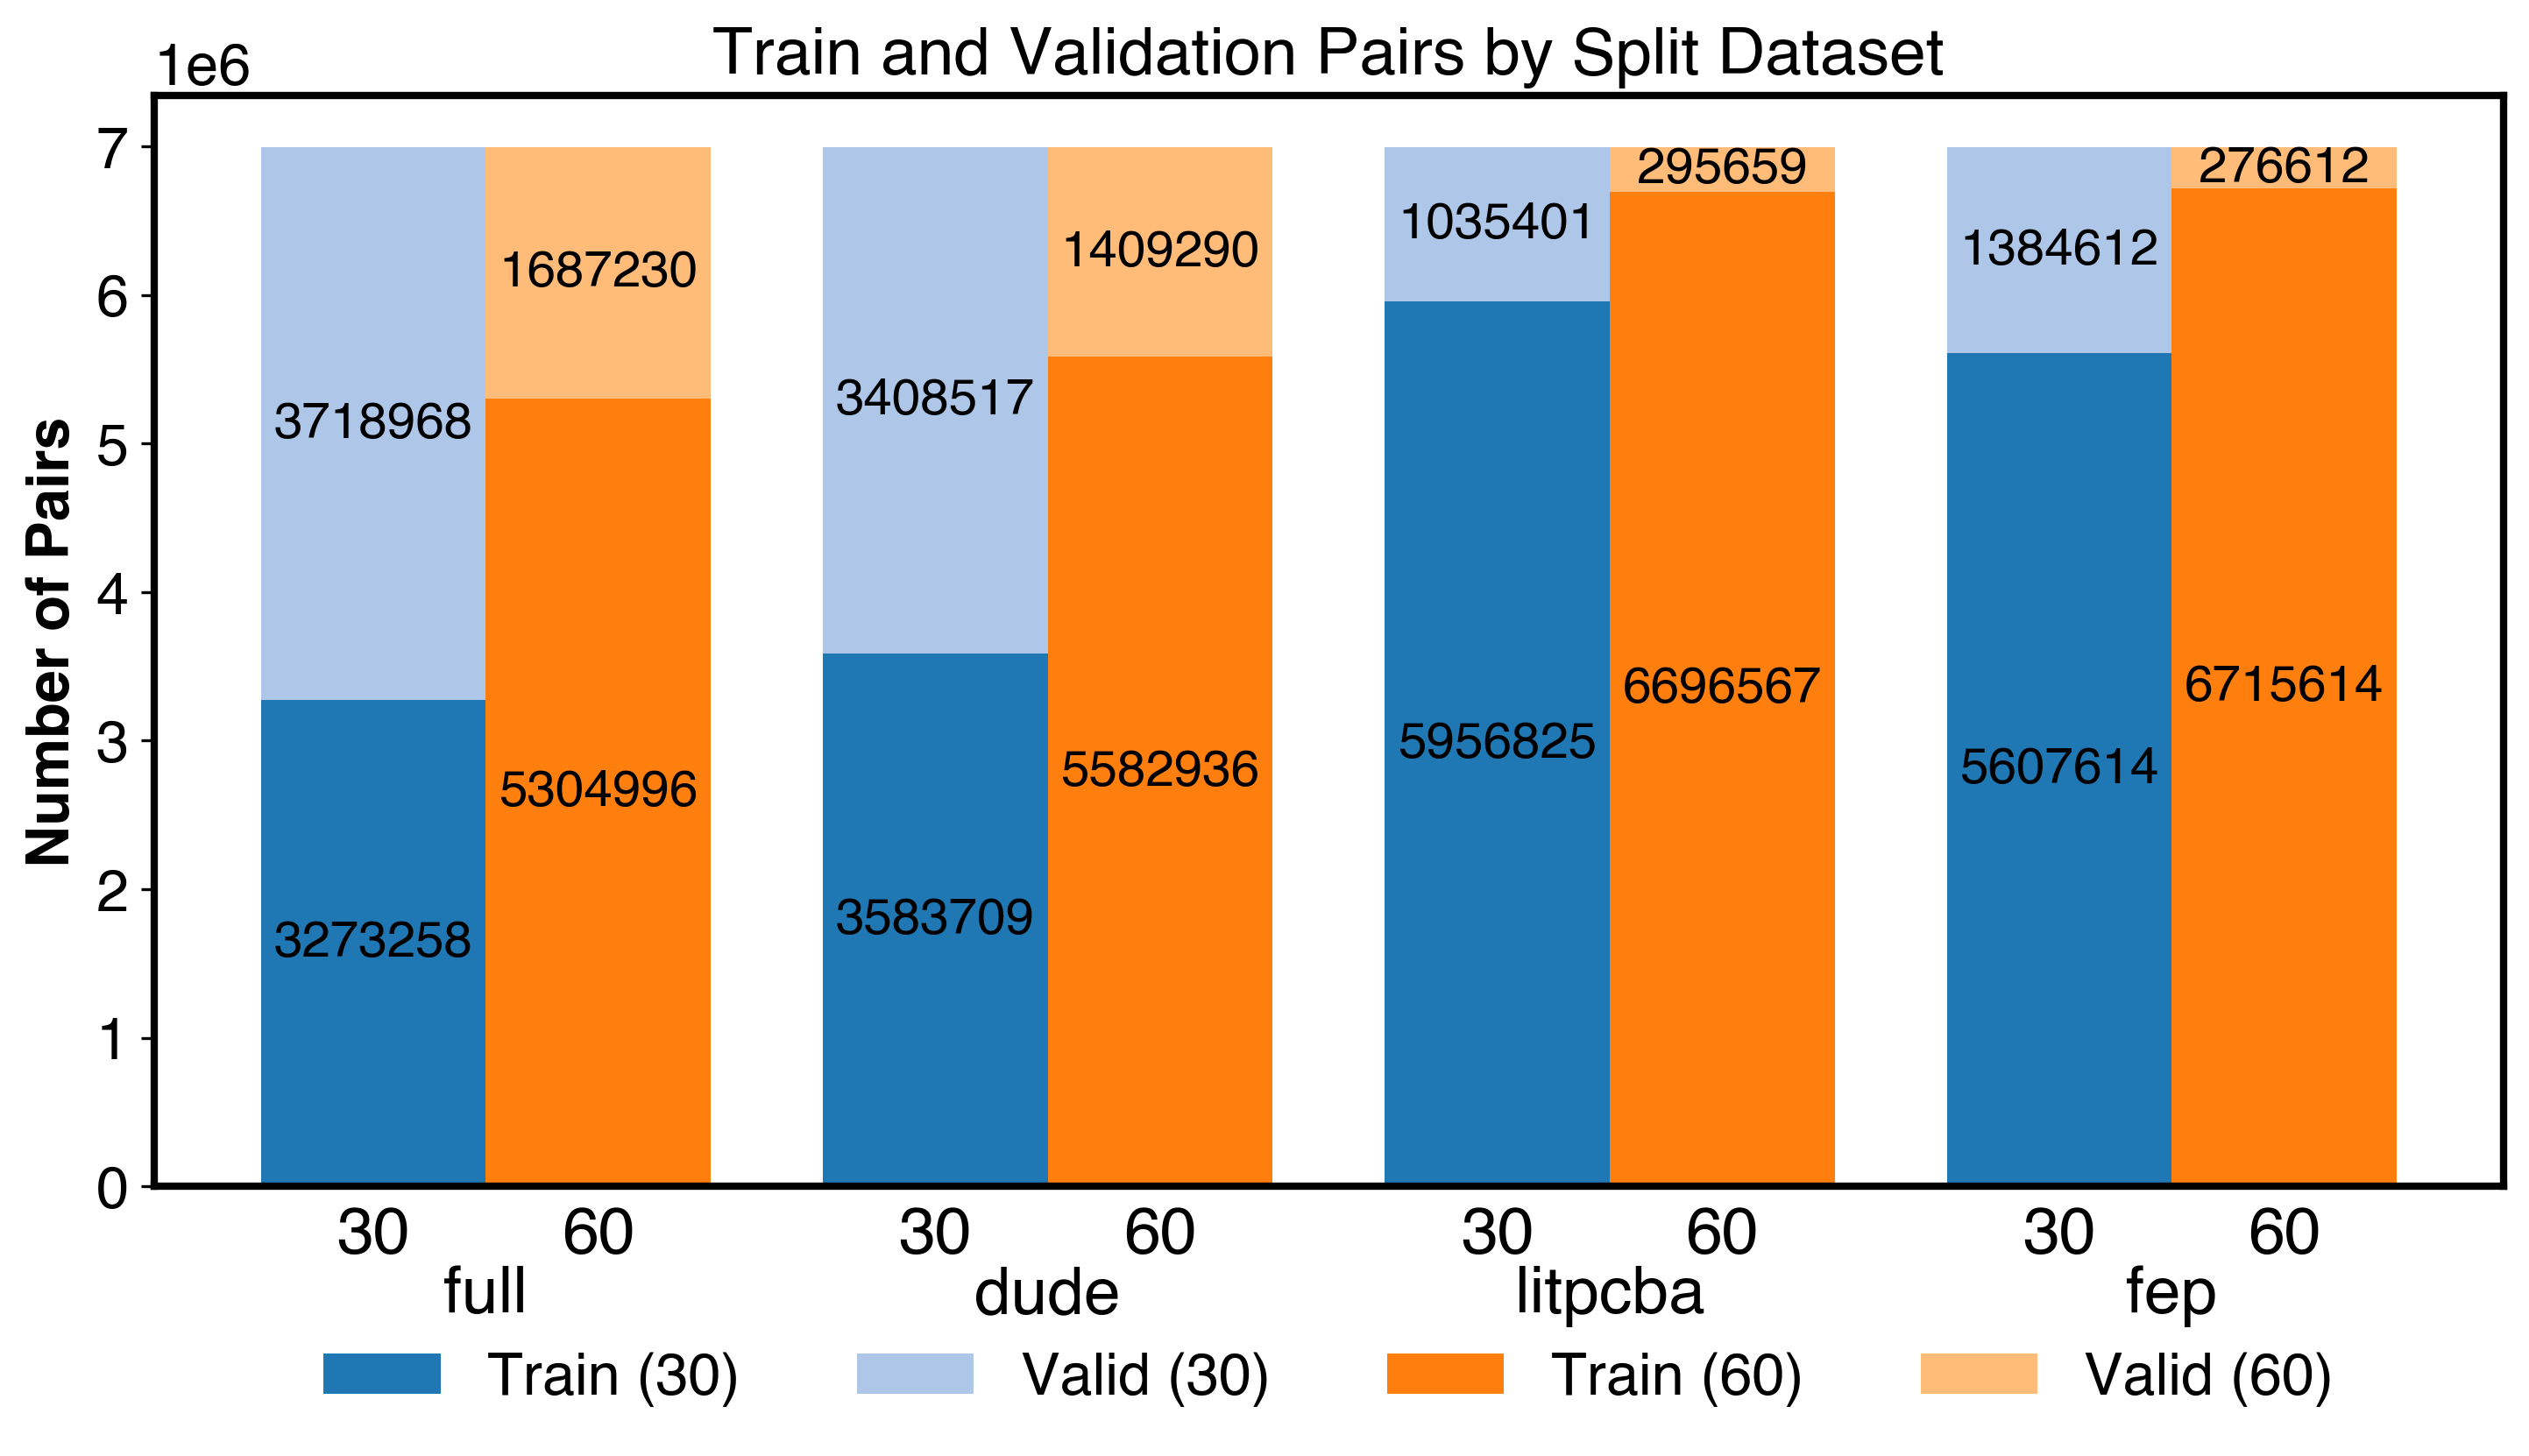

In [36]:
# Collect statistics in a dictionary
print("assay after 1024 len filter")
statistics = {}
splits = ["full", "dude", "litpcba", "fep"]
for split_name, split_30, split_60 in zip(
    splits,
    [full_data_split_30, dude_split_30, litpcba_split_30, fep_split_30],
    [full_data_split_60, dude_split_60, litpcba_split_60, fep_split_60],
):
    train_30, valid_30 = pairs_statistics_by_split(split_30, assay_pairs_filtered)
    train_60, valid_60 = pairs_statistics_by_split(split_60, assay_pairs_filtered)
    statistics[split_name] = {
        "30": {"train": train_30, "valid": valid_30},
        "60": {"train": train_60, "valid": valid_60},
    }

# Plot the results
x = range(len(splits))
width = 0.4

train_30 = [statistics[split]["30"]["train"] for split in splits]
valid_30 = [statistics[split]["30"]["valid"] for split in splits]
train_60 = [statistics[split]["60"]["train"] for split in splits]
valid_60 = [statistics[split]["60"]["valid"] for split in splits]

# Update the bar chart with scientific colors and detailed annotations
fig, ax = plt.subplots(figsize=(10, 6))

# Define scientific colors
train_30_color = "#1f77b4"  # Blue
valid_30_color = "#aec7e8"  # Light Blue
train_60_color = "#ff7f0e"  # Orange
valid_60_color = "#ffbb78"  # Light Orange

# Plot 30 split
rects1 = ax.bar(
    [i - width / 2 for i in x],
    train_30,
    width,
    label="Train (30)",
    color=train_30_color,
)
rects2 = ax.bar(
    [i - width / 2 for i in x],
    valid_30,
    width,
    bottom=train_30,
    label="Valid (30)",
    color=valid_30_color,
)

# Plot 60 split
rects3 = ax.bar(
    [i + width / 2 for i in x],
    train_60,
    width,
    label="Train (60)",
    color=train_60_color,
)
rects4 = ax.bar(
    [i + width / 2 for i in x],
    valid_60,
    width,
    bottom=train_60,
    label="Valid (60)",
    color=valid_60_color,
)

# Add detailed numbers on the bars
for rect in rects1 + rects2 + rects3 + rects4:
    height = rect.get_height()
    if height > 0:
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_y() + height / 2,
            f"{int(height)}",
            ha="center",
            va="center",
            fontsize=14,
            color="black",
        )

# Add custom x-axis labels
for i, split in enumerate(splits):
    ax.text(
        i - width / 2,
        -max(train_30 + valid_30 + train_60 + valid_60) * 0.05,
        "30",
        ha="center",
        va="center",
        color="black",
    )
    ax.text(
        i + width / 2,
        -max(train_30 + valid_30 + train_60 + valid_60) * 0.05,
        "60",
        ha="center",
        va="center",
        color="black",
    )
    ax.text(
        i,
        -max(train_30 + valid_30 + train_60 + valid_60) * 0.11,
        split,
        ha="center",
        va="center",
        color="black",
    )

# Add labels and legend
# ax.set_xlabel("Split Dataset")
ax.set_ylabel("Number of Pairs")
ax.set_title("Train and Validation Pairs by Split Dataset")
ax.set_xticks([])  # Remove default x-ticks

# Place the legend outside the figure, to the bottom
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4)

plt.tight_layout()
plt.show()

In [37]:
uniprot_pairs_30_train = {}
for key in assay_pairs_30_train:
    uniprot_id = key.split("_")[2]
    if uniprot_id not in uniprot_pairs_30_train:
        uniprot_pairs_30_train[uniprot_id] = {}
    uniprot_pairs_30_train[uniprot_id][key] = assay_pairs_30_train[key]

In [50]:
uniprot_assay_len = {}
uniprot_pairs_len = {}
for uniprot_id, assay in uniprot_pairs_30_train.items():
    uniprot_assay_len[uniprot_id] = len(assay)
    uniprot_pairs_len[uniprot_id] = sum(
        [min(len(assay_pairs_30_train[key]), 1000) for key in assay]
    )
print(f"total uniprot ids: {len(uniprot_assay_len)}")

total uniprot ids: 2476


number of assay groups per uniprot id
uniprots has assay groups == 1: 1011
uniprots has assay groups > 1: 1465
uniprots has assay groups >= 5: 776
uniprots has assay groups >= 10: 490
uniprots has assay groups >= 100: 40
uniprots has assay groups >= 200: 7


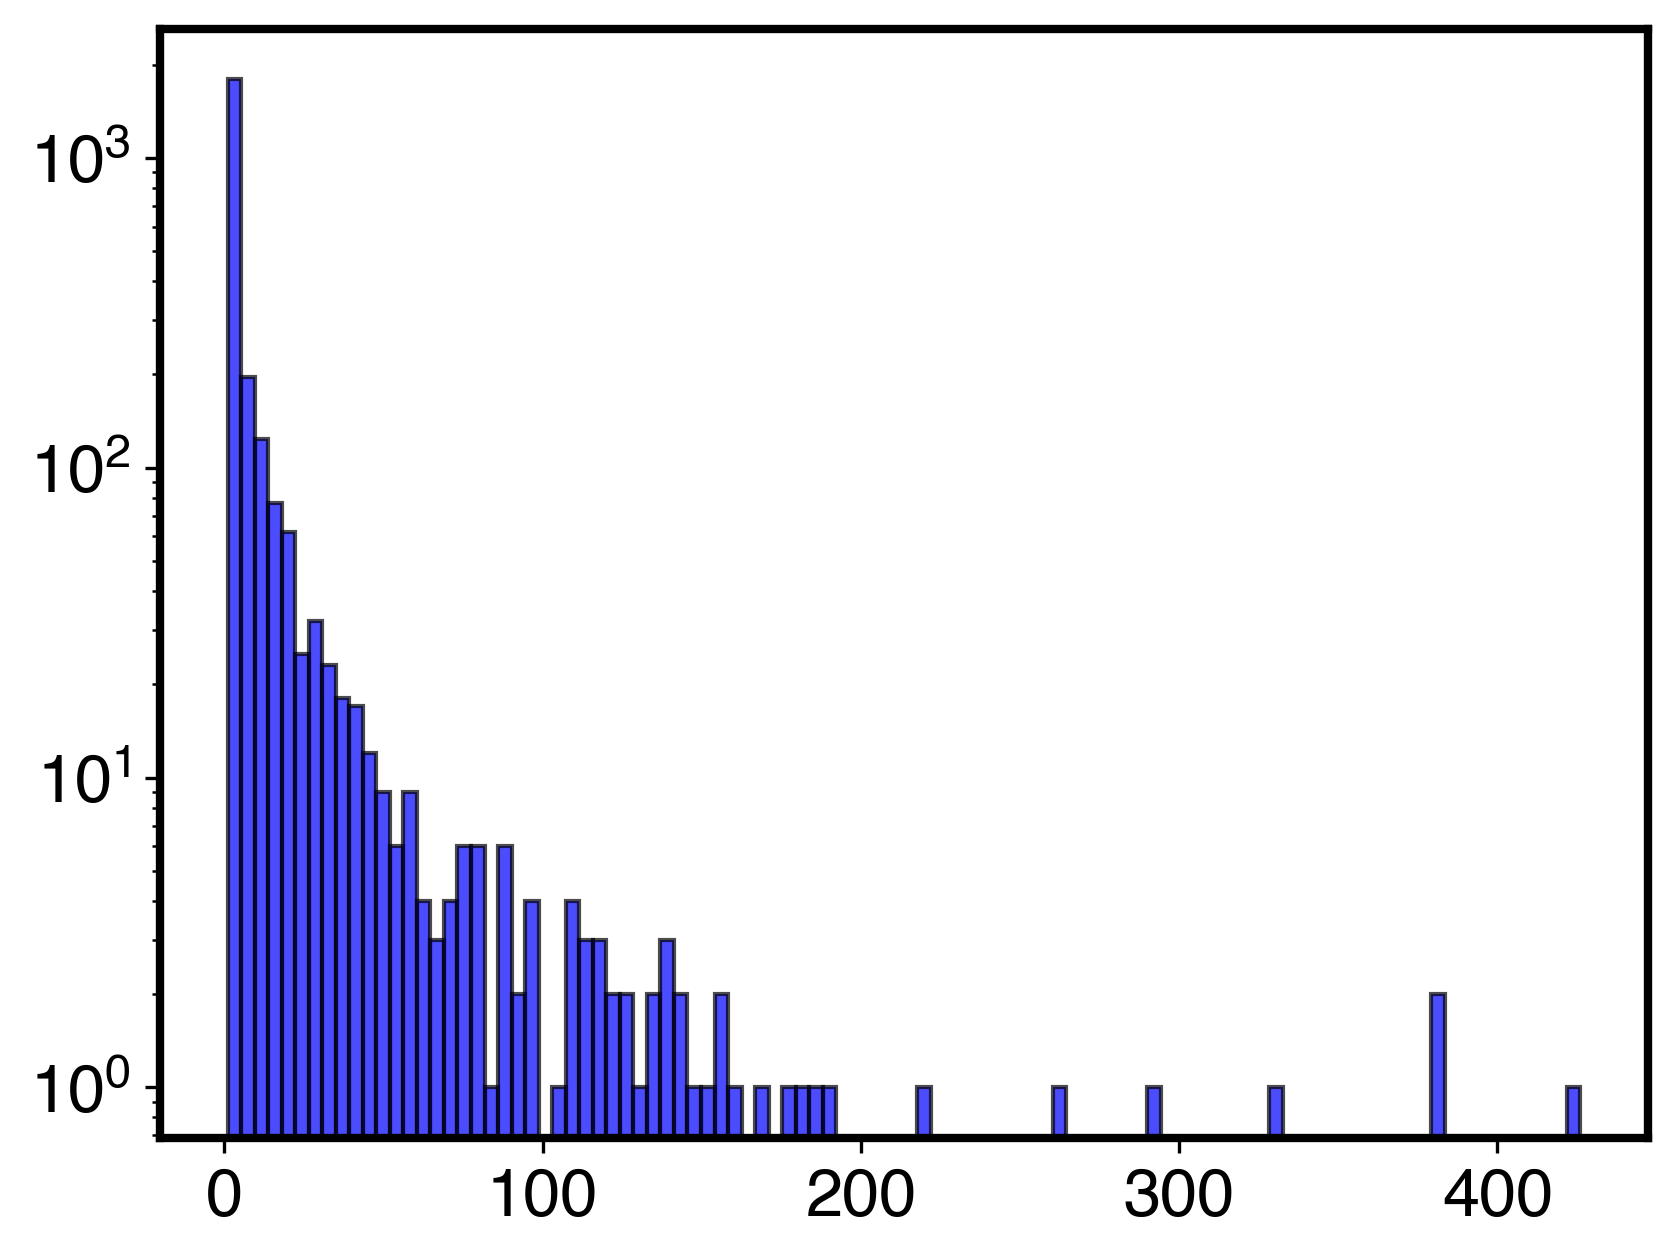

In [57]:
print("number of assay groups per uniprot id")
res = plt.hist(
    uniprot_assay_len.values(),
    bins=100,
    color="blue",
    alpha=0.7,
    edgecolor="black",
)
# log y
plt.yscale("log")

print(f"uniprots has assay groups == 1: {len([x for x in uniprot_assay_len.values() if x == 1])}")
print(f"uniprots has assay groups > 1: {len([x for x in uniprot_assay_len.values() if x > 1])}")
print(f"uniprots has assay groups >= 5: {len([x for x in uniprot_assay_len.values() if x >= 5])}")
print(f"uniprots has assay groups >= 10: {len([x for x in uniprot_assay_len.values() if x >=10])}")
print(f"uniprots has assay groups >= 100: {len([x for x in uniprot_assay_len.values() if x >= 100])}")
print(f"uniprots has assay groups >= 200: {len([x for x in uniprot_assay_len.values() if x >= 200])}")

number of pairs per uniprot id
uniprots has pairs == 1: 151
uniprots has pairs > 1: 2325
uniprots has pairs >= 10: 1924
uniprots has pairs >= 100: 1310
uniprots has pairs >= 1000: 649
uniprots has pairs >= 10000: 66


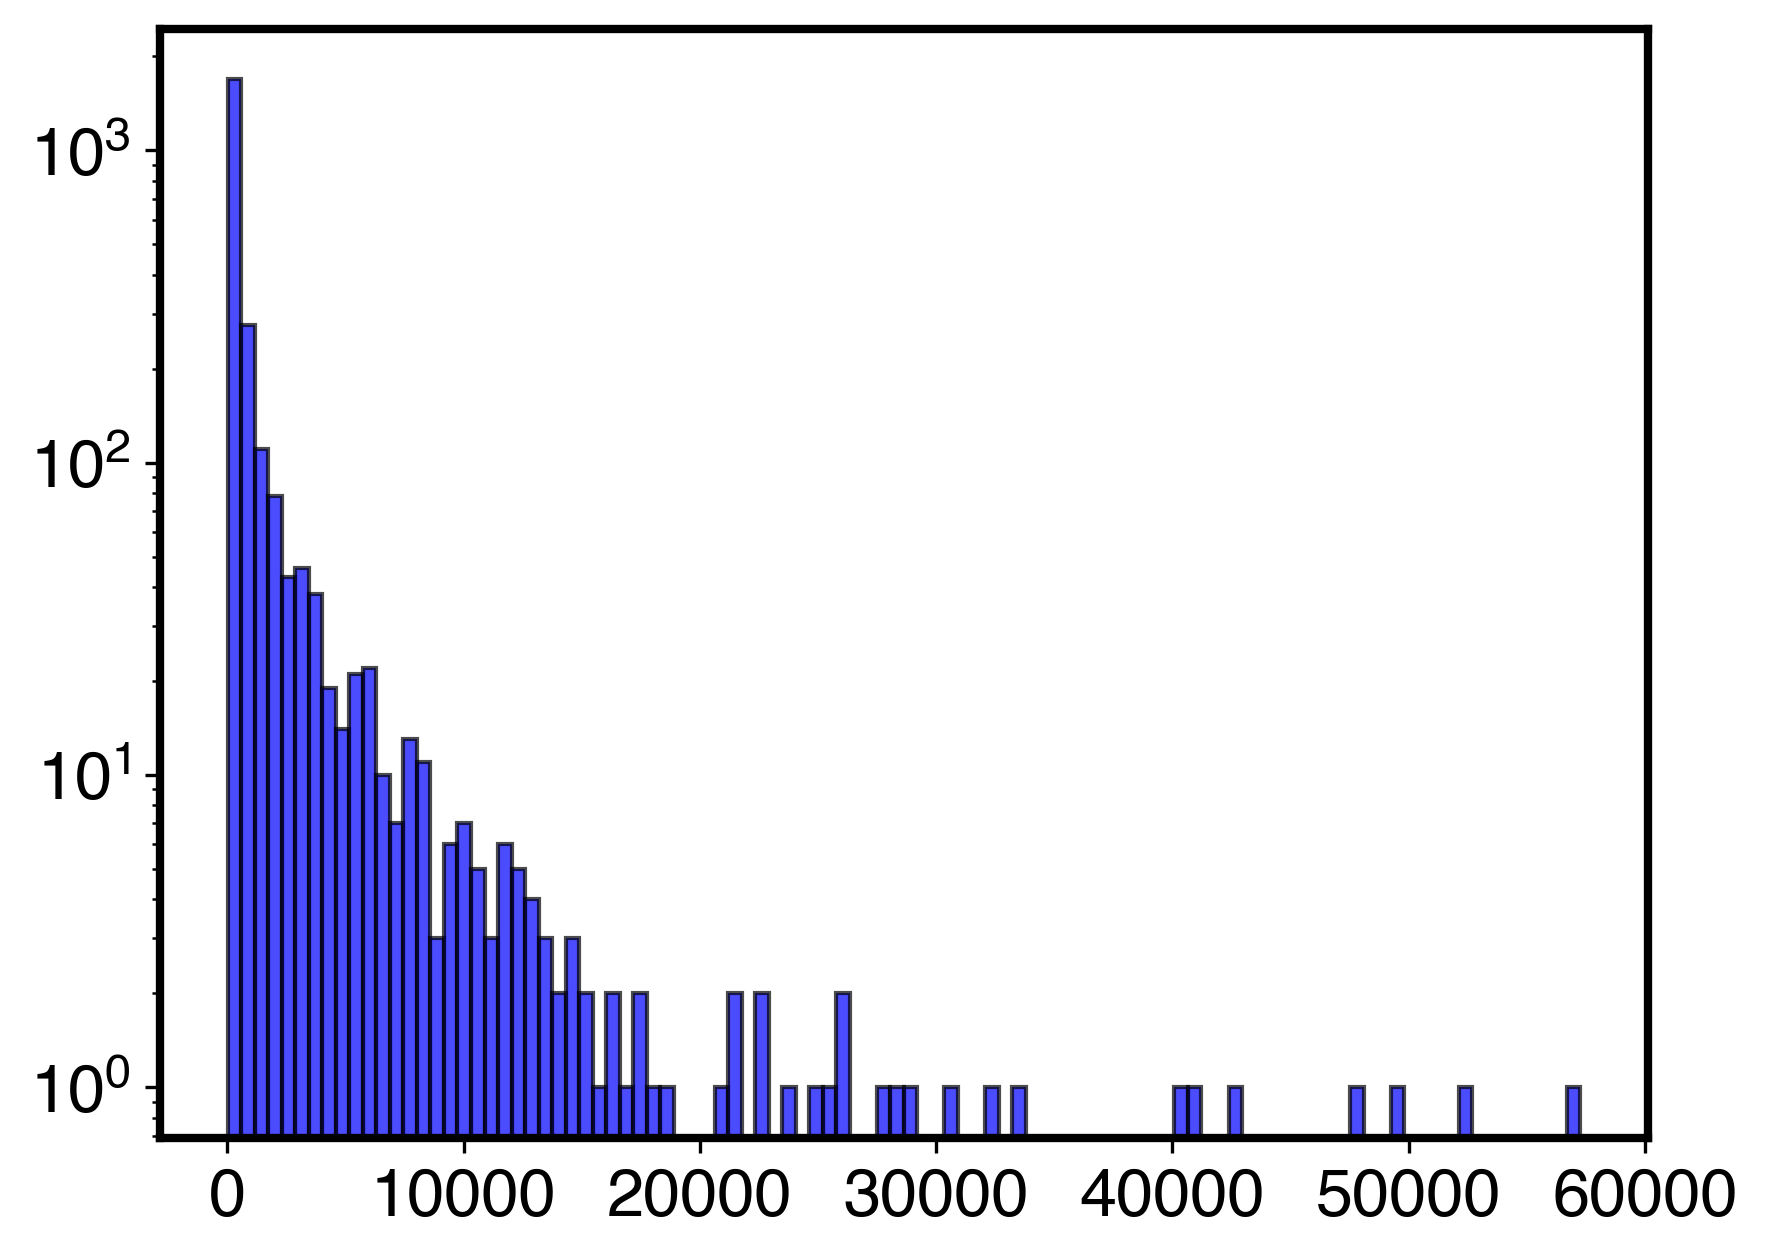

In [59]:
print("number of pairs per uniprot id")
res = plt.hist(
    uniprot_pairs_len.values(),
    bins=100,
    color="blue",
    alpha=0.7,
    edgecolor="black",
)
# log y
plt.yscale("log")

print(f"uniprots has pairs == 1: {len([x for x in uniprot_pairs_len.values() if x == 1])}")
print(f"uniprots has pairs > 1: {len([x for x in uniprot_pairs_len.values() if x > 1])}")
print(f"uniprots has pairs >= 10: {len([x for x in uniprot_pairs_len.values() if x >= 10])}")
print(f"uniprots has pairs >= 100: {len([x for x in uniprot_pairs_len.values() if x >= 100])}")
print(f"uniprots has pairs >= 1000: {len([x for x in uniprot_pairs_len.values() if x >= 1000])}")
print(f"uniprots has pairs >= 10000: {len([x for x in uniprot_pairs_len.values() if x >= 10000])}")